In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
print("cell testing....")

cell testing....


In [2]:
# ================================
# Cell 1: Enhanced Imports & Utility Functions
# Purpose: Import all necessary libraries and define helper functions for metrics and visualization
# Runtime: ~5-10 seconds
# ================================

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=Warning)

# Core libraries
import os
import cv2
import numpy as np
from tqdm import tqdm
import time

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Model
import timm

# Metrics & Visualization
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


# ================================
# Enhanced Compute Metrics Function
# ================================
def compute_metrics(y_true, y_pred):
    """
    Compute comprehensive classification metrics
    
    Args:
        y_true: Ground truth labels (numpy array)
        y_pred: Predicted labels (numpy array)
    
    Returns:
        Dictionary containing all metrics
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'confusion_matrix': cm
    }


# ================================
# Memory-Safe PyTorch Dataset
# ================================
class LiverSliceDataset(Dataset):
    """
    Custom Dataset for liver tumor classification
    Loads images on-the-fly to save memory
    """
    def __init__(self, image_dir, mask_dir, image_files, mask_files, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        # Load image: BGR -> Gray -> Resize -> Normalize -> 3-channel
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (224, 224))
        img = img.astype("float32") / 255.0
        img = np.repeat(img[..., None], 3, axis=2)  # HWC format

        # Load mask and create binary label
        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)
        label = 1 if mask.sum() > 0 else 0  # 1: tumor present, 0: no tumor

        # Convert to tensor (CHW format)
        img = torch.tensor(img).permute(2, 0, 1)  # C, H, W
        label = torch.tensor(label, dtype=torch.long)

        if self.transform:
            img = self.transform(img)

        return img, label


print("✓ Dataset class and utility functions defined!")

✓ All libraries imported successfully!
PyTorch version: 2.6.0+cu124
CUDA available: True
✓ Dataset class and utility functions defined!


In [3]:
# ================================
# Cell 2: Data Loading & Preparation
# Purpose: Load data, create stratified train/val split, and prepare DataLoaders
# Runtime: ~30-60 seconds (depends on dataset size)
# ================================

# Define directories
image_dir = "/kaggle/input/litsdataset2/images"
mask_dir = "/kaggle/input/litsdataset2/masks"

# Get sorted file lists
image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

print(f"Total images found: {len(image_files)}")
print(f"Total masks found: {len(mask_files)}")


# ================================
# Quick Labeling for Stratification
# ================================
def quick_label(mask_path):
    """Fast label extraction for stratified split"""
    m = cv2.imread(mask_path, 0)
    m = cv2.resize(m, (224, 224), interpolation=cv2.INTER_NEAREST)
    return 1 if m.sum() > 0 else 0


print("\n🔍 Extracting labels for stratified split...")
labels = []
for mf in tqdm(mask_files, desc="Labeling"):
    labels.append(quick_label(os.path.join(mask_dir, mf)))

# Count distribution
tumor_count = sum(labels)
normal_count = len(labels) - tumor_count

print(f"\n📊 Dataset Distribution:")
print(f"   Tumor slices: {tumor_count} ({tumor_count/len(labels)*100:.1f}%)")
print(f"   Normal slices: {normal_count} ({normal_count/len(labels)*100:.1f}%)")
print(f"   Total: {len(labels)}")


# ================================
# Train/Validation Split (Stratified)
# ================================
print("\n✂️  Creating stratified train/val split (80/20)...")
img_train, img_val, mask_train, mask_val = train_test_split(
    image_files, mask_files, 
    test_size=0.20, 
    random_state=42, 
    stratify=labels
)

print(f"   Train slices: {len(img_train)}")
print(f"   Val slices: {len(img_val)}")


# ================================
# Create Datasets & DataLoaders
# ================================
print("\n🔄 Creating PyTorch Datasets...")
train_ds = LiverSliceDataset(image_dir, mask_dir, img_train, mask_train)
val_ds = LiverSliceDataset(image_dir, mask_dir, img_val, mask_val)

# DataLoader configuration
batch_size = 16
num_workers = 2

print(f"\n🚀 Creating DataLoaders (batch_size={batch_size})...")
train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers, 
    pin_memory=True
)

val_loader = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers, 
    pin_memory=True
)

print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")

# Estimate time per epoch
samples_per_sec = 100  # Conservative estimate
train_time_estimate = (len(img_train) / samples_per_sec) / 60
val_time_estimate = (len(img_val) / samples_per_sec) / 60

print(f"\n⏱️  Estimated time per epoch:")
print(f"   Training: ~{train_time_estimate:.1f} minutes")
print(f"   Validation: ~{val_time_estimate:.1f} minutes")
print(f"   Total: ~{train_time_estimate + val_time_estimate:.1f} minutes/epoch")

print("\n✓ Data preparation complete!")

Total images found: 58638
Total masks found: 58638

🔍 Extracting labels for stratified split...


Labeling: 100%|██████████| 58638/58638 [04:48<00:00, 203.60it/s]


📊 Dataset Distribution:
   Tumor slices: 19151 (32.7%)
   Normal slices: 39487 (67.3%)
   Total: 58638

✂️  Creating stratified train/val split (80/20)...
   Train slices: 46910
   Val slices: 11728

🔄 Creating PyTorch Datasets...

🚀 Creating DataLoaders (batch_size=16)...
   Train batches: 2932
   Val batches: 733

⏱️  Estimated time per epoch:
   Training: ~7.8 minutes
   Validation: ~2.0 minutes
   Total: ~9.8 minutes/epoch

✓ Data preparation complete!


In [ ]:
# ================================
# Cell 3: Training Loop - Full 30 Epochs (No Early Stopping)
# Purpose: Train Swin Transformer for full 30 epochs and track best model
# Runtime: ~30-60 minutes (depends on dataset size)
# ================================

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Training device: {device}")

# ================================
# Model Initialization
# ================================
model_name = "swin_tiny_patch4_window7_224"  # Options: swin_tiny, swin_small, swin_base
print(f"\n🏗️  Initializing {model_name}...")
model = timm.create_model(model_name, pretrained=True, num_classes=2)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")


# ================================
# Training Configuration
# ================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# Training parameters
num_epochs = 50  # Fixed 30 epochs - NO early stopping
save_path = "/kaggle/working/swin_best.pth"

print(f"\n⚙️  Training Configuration:")
print(f"   Total epochs: {num_epochs}")
print(f"   Early stopping: DISABLED (will run full {num_epochs} epochs)")
print(f"   Learning rate: 3e-4")
print(f"   Weight decay: 1e-5")


# ================================
# Tracking Variables
# ================================
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'learning_rates': []
}

best_val_f1 = 0.0
best_epoch = -1
best_metrics = None

# For ROC curve
best_val_probs = None
best_val_targets = None

print("\n" + "="*60)
print("🚀 STARTING TRAINING (FULL 30 EPOCHS)")
print("="*60)

start_time = time.time()


# ================================
# Training Loop (30 Epochs)
# ================================
for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()
    
    # ------------------------------------
    # TRAINING PHASE
    # ------------------------------------
    model.train()
    train_losses = []
    train_preds_all = []
    train_targets_all = []
    
    train_pbar = tqdm(train_loader, desc=f"📈 Epoch {epoch}/{num_epochs} [Train]")
    for imgs, labels in train_pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_losses.append(loss.item())
        
        # Track predictions for training accuracy
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_preds_all.extend(preds)
        train_targets_all.extend(labels.cpu().numpy())
        
        # Update progress bar
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate training metrics
    train_acc = accuracy_score(train_targets_all, train_preds_all)
    avg_train_loss = np.mean(train_losses)
    
    
    # ------------------------------------
    # VALIDATION PHASE
    # ------------------------------------
    model.eval()
    val_losses = []
    all_preds = []
    all_targets = []
    all_probs = []  # For ROC curve
    
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"📊 Epoch {epoch}/{num_epochs} [Val]  ")
        for imgs, labels in val_pbar:
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            
            val_losses.append(loss.item())
            
            # Get predictions and probabilities
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()  # Prob of class 1
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())
            
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    
    # ------------------------------------
    # COMPUTE METRICS
    # ------------------------------------
    metrics = compute_metrics(all_targets, all_preds)
    avg_val_loss = np.mean(val_losses)
    
    # Store in history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(metrics['accuracy'])
    history['val_precision'].append(metrics['precision'])
    history['val_recall'].append(metrics['recall'])
    history['val_f1'].append(metrics['f1_score'])
    history['learning_rates'].append(optimizer.param_groups[0]['lr'])
    
    
    # ------------------------------------
    # PRINT EPOCH SUMMARY
    # ------------------------------------
    epoch_time = time.time() - epoch_start
    
    print(f"\n{'='*60}")
    print(f"📊 EPOCH {epoch}/{num_epochs} SUMMARY (Time: {epoch_time:.1f}s)")
    print(f"{'='*60}")
    print(f"Train → Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   → Loss: {avg_val_loss:.4f} | Acc: {metrics['accuracy']:.4f}")
    print(f"        Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f} | F1: {metrics['f1_score']:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    
    # ------------------------------------
    # TRACK BEST MODEL (but don't stop)
    # ------------------------------------
    if metrics['f1_score'] > best_val_f1:
        improvement = metrics['f1_score'] - best_val_f1
        best_val_f1 = metrics['f1_score']
        best_epoch = epoch
        best_metrics = metrics
        best_val_probs = all_probs
        best_val_targets = all_targets
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': metrics,
            'history': history
        }, save_path)
        
        print(f"🔥 NEW BEST MODEL! F1: {metrics['f1_score']:.4f} (+{improvement:.4f}) → Saved!")
    else:
        print(f"📌 Current best: Epoch {best_epoch} (F1: {best_val_f1:.4f})")
    
    # Step scheduler
    scheduler.step()
    print()  # Empty line for readability


# ================================
# TRAINING COMPLETE - FINAL SUMMARY
# ================================
total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"🎉 TRAINING COMPLETED - ALL 30 EPOCHS!")
print(f"{'='*60}")
print(f"Total training time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f"Average time per epoch: {total_time/num_epochs:.1f} seconds")

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL FOUND AT EPOCH {best_epoch}")
print(f"{'='*60}")
print(f"\n📊 Best Model Performance Metrics:")
print(f"   ├─ Accuracy : {best_metrics['accuracy']*100:.2f}%")
print(f"   ├─ Precision: {best_metrics['precision']*100:.2f}%")
print(f"   ├─ Recall   : {best_metrics['recall']*100:.2f}%")
print(f"   └─ F1-Score : {best_metrics['f1_score']*100:.2f}%")

print(f"\n📈 Epoch-wise Best F1 Tracking:")
# Find top 5 epochs by F1 score
f1_with_epochs = [(i+1, f1) for i, f1 in enumerate(history['val_f1'])]
top_5_epochs = sorted(f1_with_epochs, key=lambda x: x[1], reverse=True)[:5]

for rank, (ep, f1) in enumerate(top_5_epochs, 1):
    marker = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else f"{rank}."
    print(f"   {marker} Epoch {ep:2d}: F1 = {f1:.4f}")

print(f"\n📉 Training Progress:")
print(f"   ├─ Initial Train Loss: {history['train_loss'][0]:.4f}")
print(f"   ├─ Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"   ├─ Initial Val Loss: {history['val_loss'][0]:.4f}")
print(f"   └─ Final Val Loss: {history['val_loss'][-1]:.4f}")

print(f"\n💾 Saving training history and final metrics...")
np.save('/kaggle/working/training_history.npy', history)
np.save('/kaggle/working/best_metrics.npy', best_metrics)
np.save('/kaggle/working/best_val_probs.npy', best_val_probs)
np.save('/kaggle/working/best_val_targets.npy', best_val_targets)

# Save epoch-wise summary to text file
with open('/kaggle/working/training_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("TRAINING SUMMARY - 30 EPOCHS\n")
    f.write("="*60 + "\n\n")
    f.write(f"Best Epoch: {best_epoch}\n")
    f.write(f"Best F1-Score: {best_metrics['f1_score']:.4f}\n")
    f.write(f"Best Accuracy: {best_metrics['accuracy']:.4f}\n")
    f.write(f"Best Precision: {best_metrics['precision']:.4f}\n")
    f.write(f"Best Recall: {best_metrics['recall']:.4f}\n\n")
    f.write("Epoch-wise Validation F1 Scores:\n")
    f.write("-"*60 + "\n")
    for ep, f1 in enumerate(history['val_f1'], 1):
        marker = " ← BEST" if ep == best_epoch else ""
        f.write(f"Epoch {ep:2d}: {f1:.4f}{marker}\n")

print("✓ All metrics saved successfully!")
print("\n📁 Generated Files:")
print("   ├─ swin_best.pth (best model checkpoint)")
print("   ├─ training_history.npy")
print("   ├─ best_metrics.npy")
print("   ├─ best_val_probs.npy")
print("   ├─ best_val_targets.npy")
print("   └─ training_summary.txt")

print("\n" + "="*60)
print("✅ Ready for visualization (run Cell 4 and Cell 5)")
print("="*60)

🖥️  Training device: cuda

🏗️  Initializing swin_tiny_patch4_window7_224...
   Total parameters: 27,520,892
   Trainable parameters: 27,520,892

⚙️  Training Configuration:
   Total epochs: 50
   Early stopping: DISABLED (will run full 50 epochs)
   Learning rate: 3e-4
   Weight decay: 1e-5

🚀 STARTING TRAINING (FULL 30 EPOCHS)


📊 Epoch 1/50 [Val]  : 100%|██████████| 733/733 [01:01<00:00, 11.86it/s, loss=0.0600]



📊 EPOCH 1/50 SUMMARY (Time: 398.3s)
Train → Loss: 0.1262 | Acc: 0.9535
Val   → Loss: 0.0486 | Acc: 0.9817
        Precision: 0.9657 | Recall: 0.9786 | F1: 0.9721
LR: 0.000300
🔥 NEW BEST MODEL! F1: 0.9721 (+0.9721) → Saved!



📊 Epoch 2/50 [Val]  : 100%|██████████| 733/733 [01:05<00:00, 11.19it/s, loss=0.0386]



📊 EPOCH 2/50 SUMMARY (Time: 401.6s)
Train → Loss: 0.0754 | Acc: 0.9736
Val   → Loss: 0.0427 | Acc: 0.9870
        Precision: 0.9857 | Recall: 0.9744 | F1: 0.9800
LR: 0.000293
🔥 NEW BEST MODEL! F1: 0.9800 (+0.0079) → Saved!



...

📊 Epoch 46/50 [Val]  : 100%|██████████| 733/733 [00:52<00:00, 14.02it/s, loss=0.0010]



📊 EPOCH 46/50 SUMMARY (Time: 387.1s)
Train → Loss: 0.0104 | Acc: 0.9969
Val   → Loss: 0.0148 | Acc: 0.9950
        Precision: 0.9966 | Recall: 0.9880 | F1: 0.9923
LR: 0.000150
📌 Current best: Epoch 30 (F1: 0.9950)



📊 Epoch 49/50 [Val]  : 100%|██████████| 733/733 [00:53<00:00, 13.65it/s, loss=0.0000]



📊 EPOCH 49/50 SUMMARY (Time: 382.7s)
Train → Loss: 0.0019 | Acc: 0.9995
Val   → Loss: 0.0223 | Acc: 0.9953
        Precision: 0.9950 | Recall: 0.9906 | F1: 0.9928
LR: 0.000029
📌 Current best: Epoch 30 (F1: 0.9950)



📊 Epoch 50/50 [Val]  :  50%|████▉     | 363/733 [00:26<00:28, 13.18it/s, loss=0.0000]

📊 Generating comprehensive evaluation visualizations...

1️⃣  Generating Confusion Matrix...
   ✓ Saved: 1_confusion_matrix.png


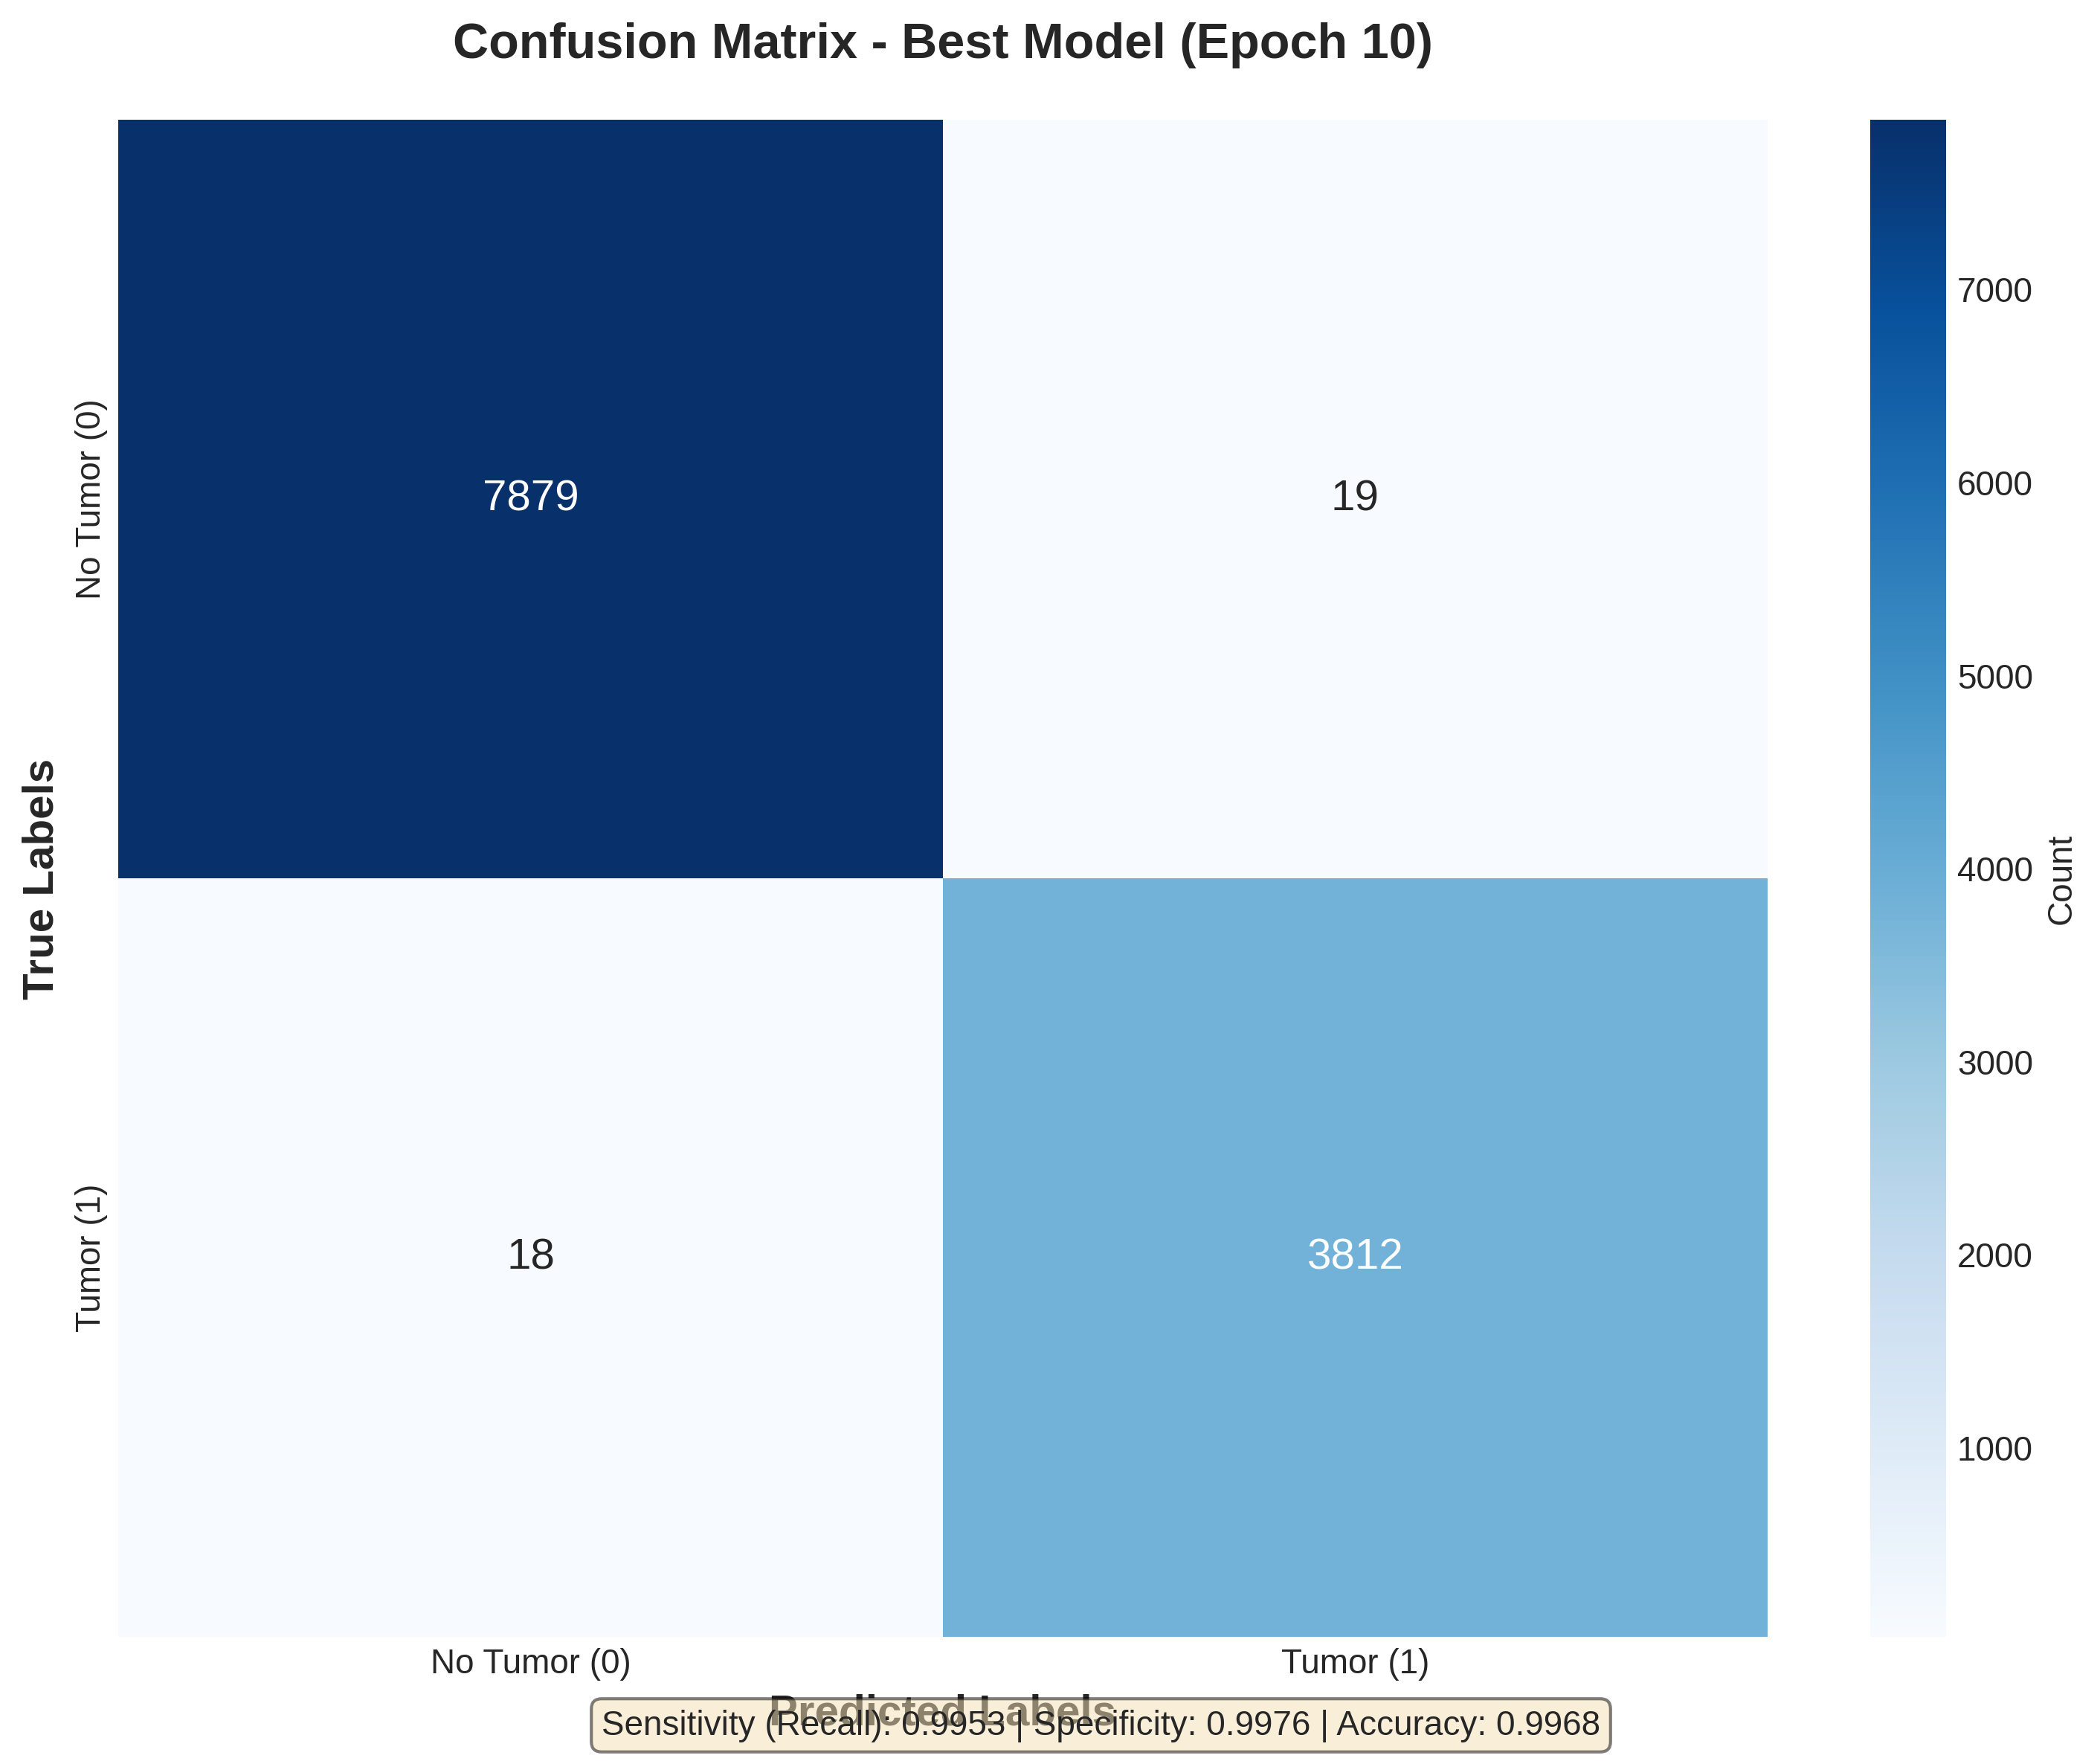

2️⃣  Generating Accuracy & Loss Curves (Combined)...
4️⃣  Generating F1-Score Curve...
   ✓ Saved: 4_f1_score_curve.png


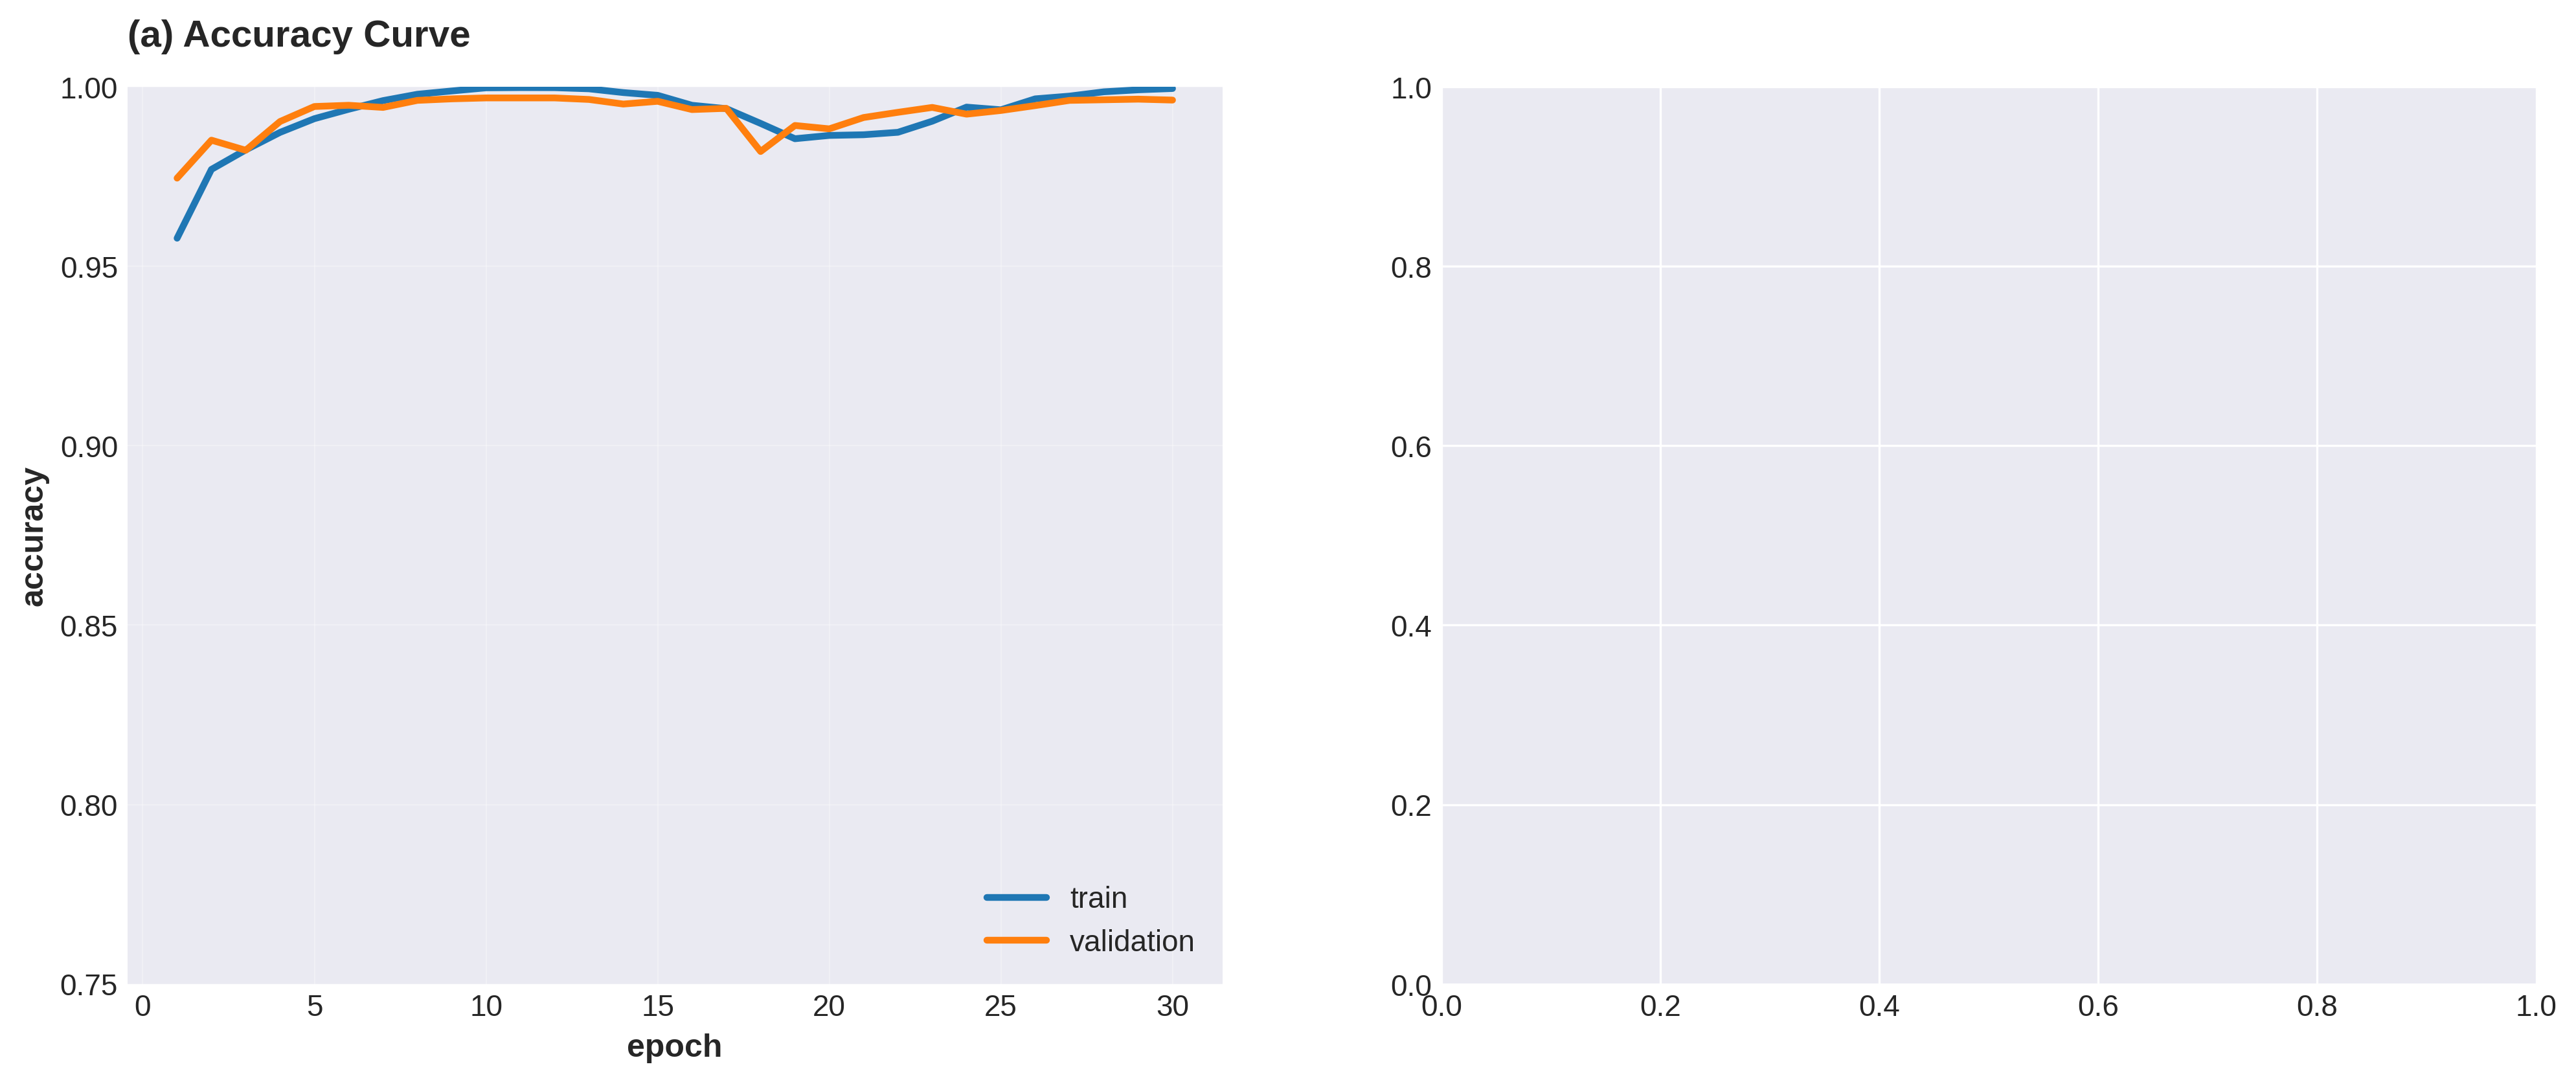

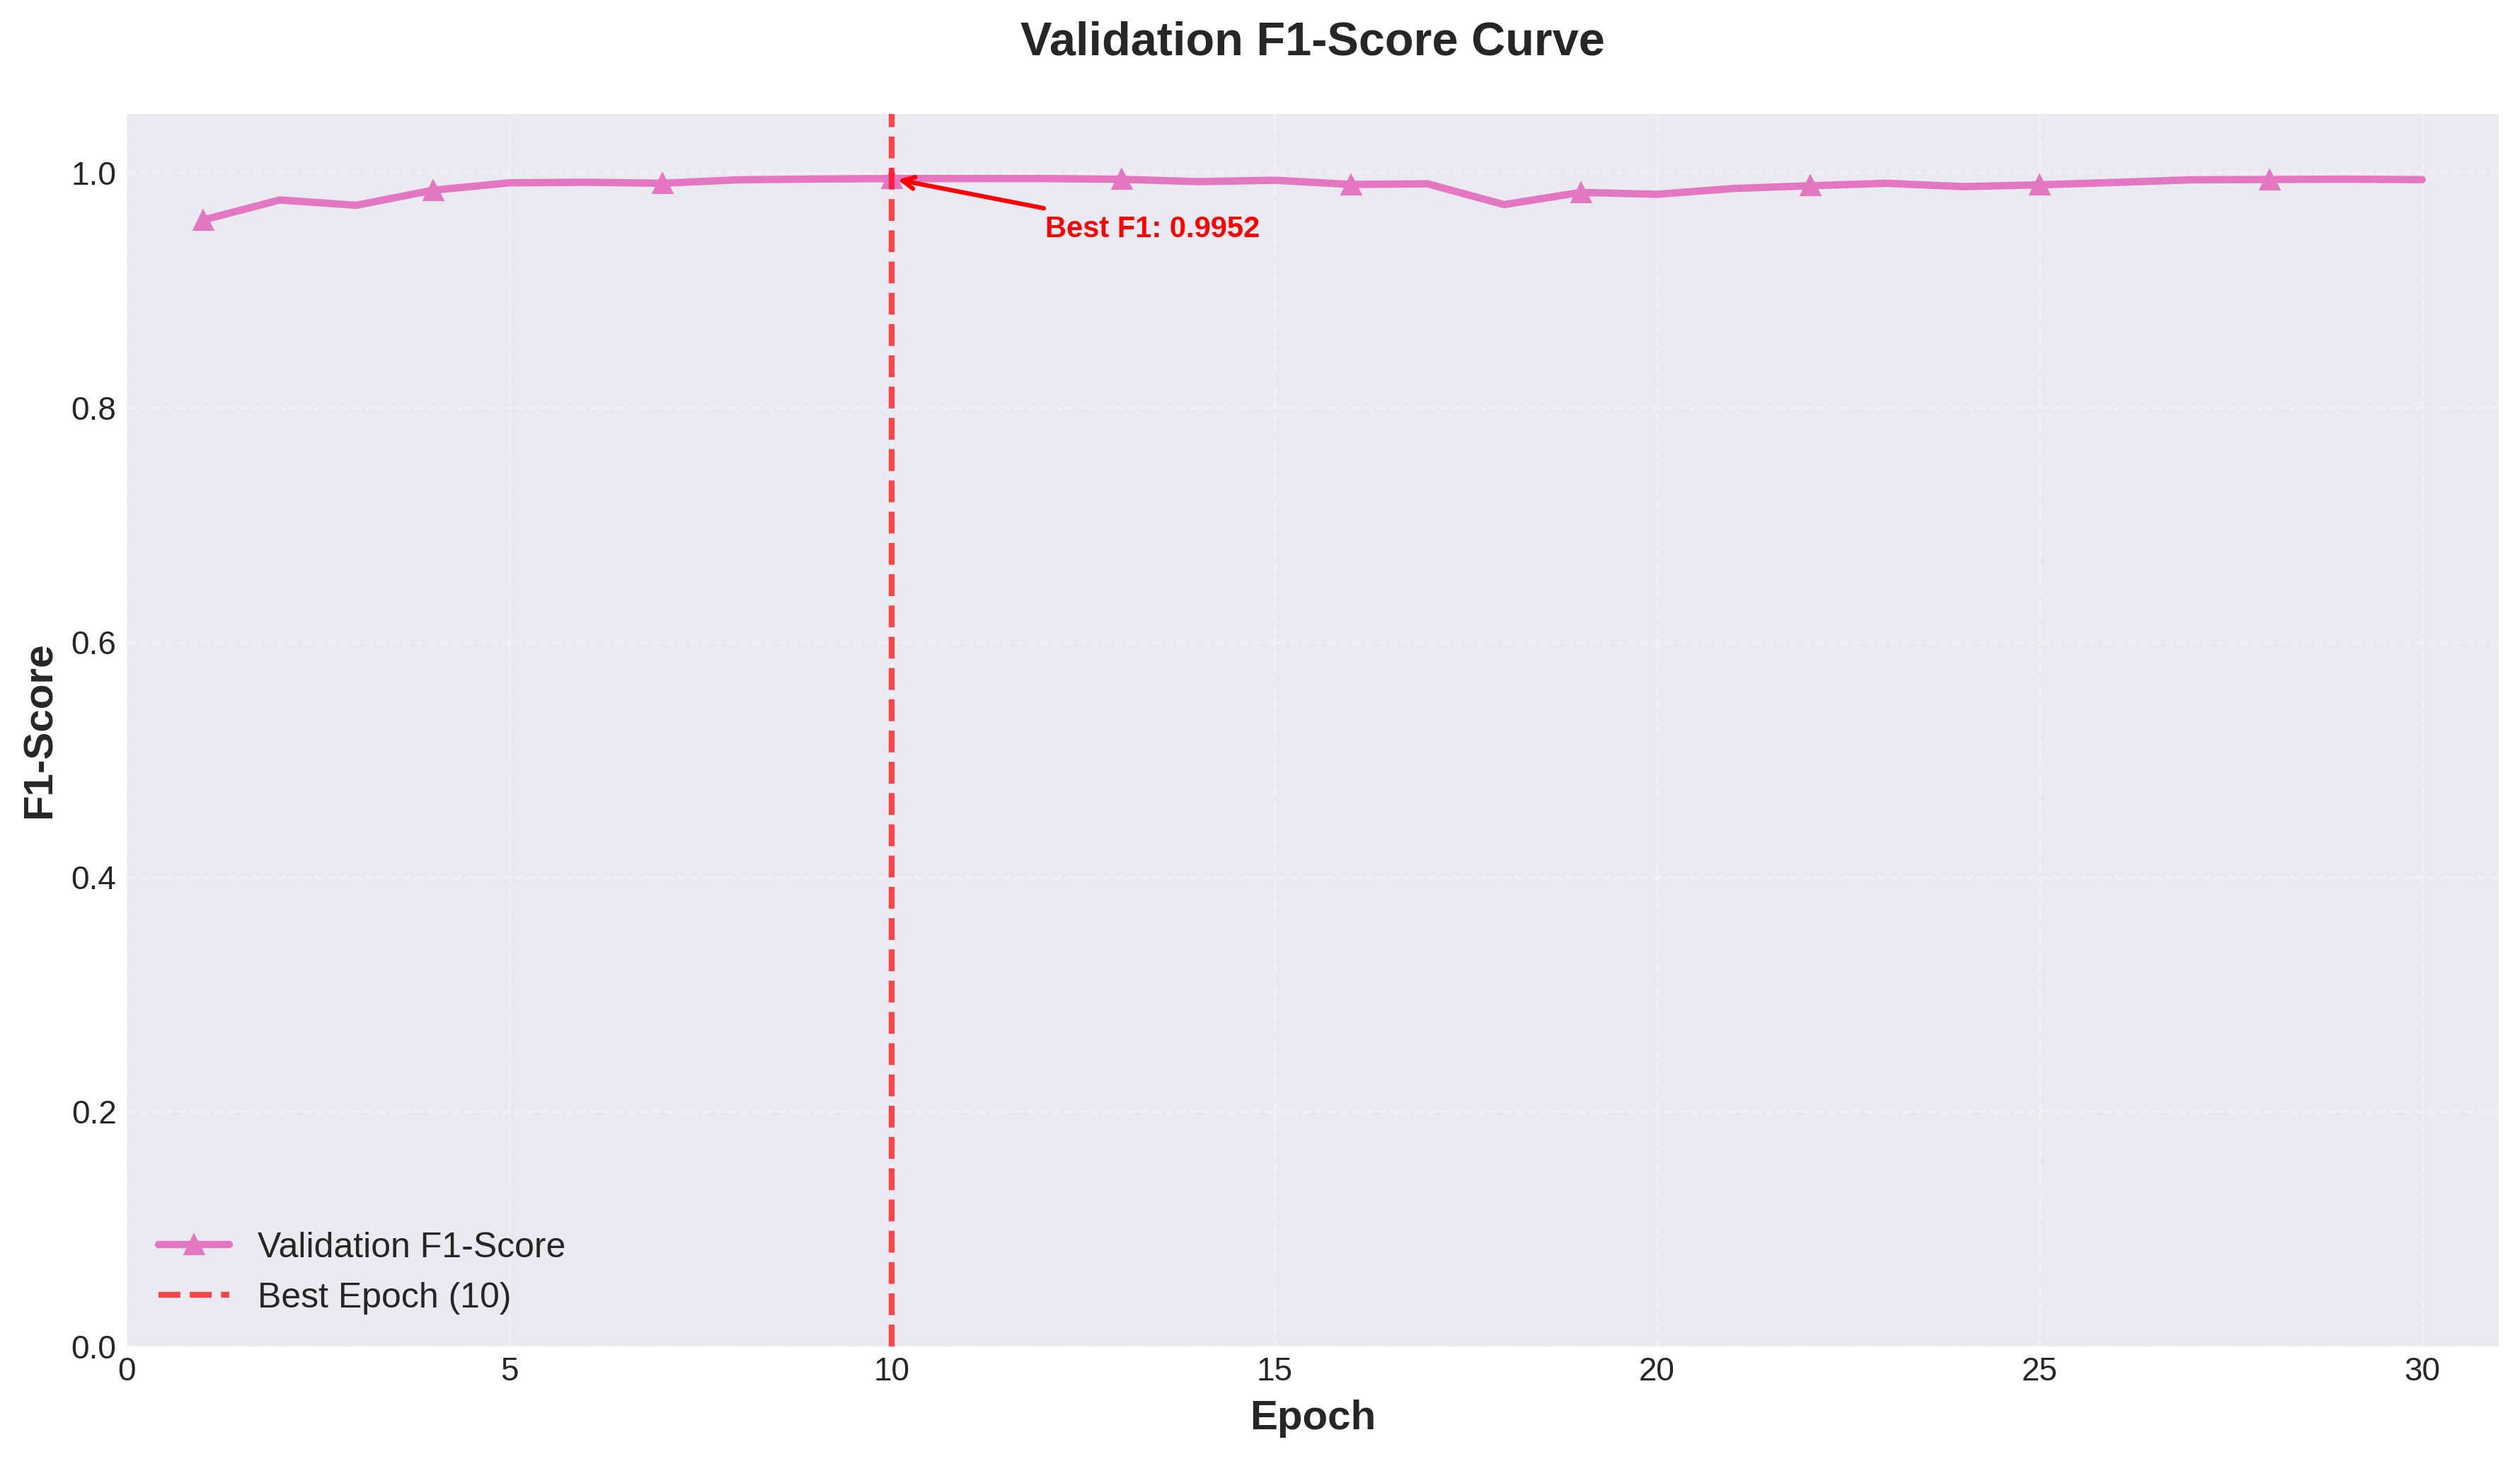

5️⃣  Generating Precision/Recall/F1 Combined Curve...
   ✓ Saved: 5_precision_recall_f1.png


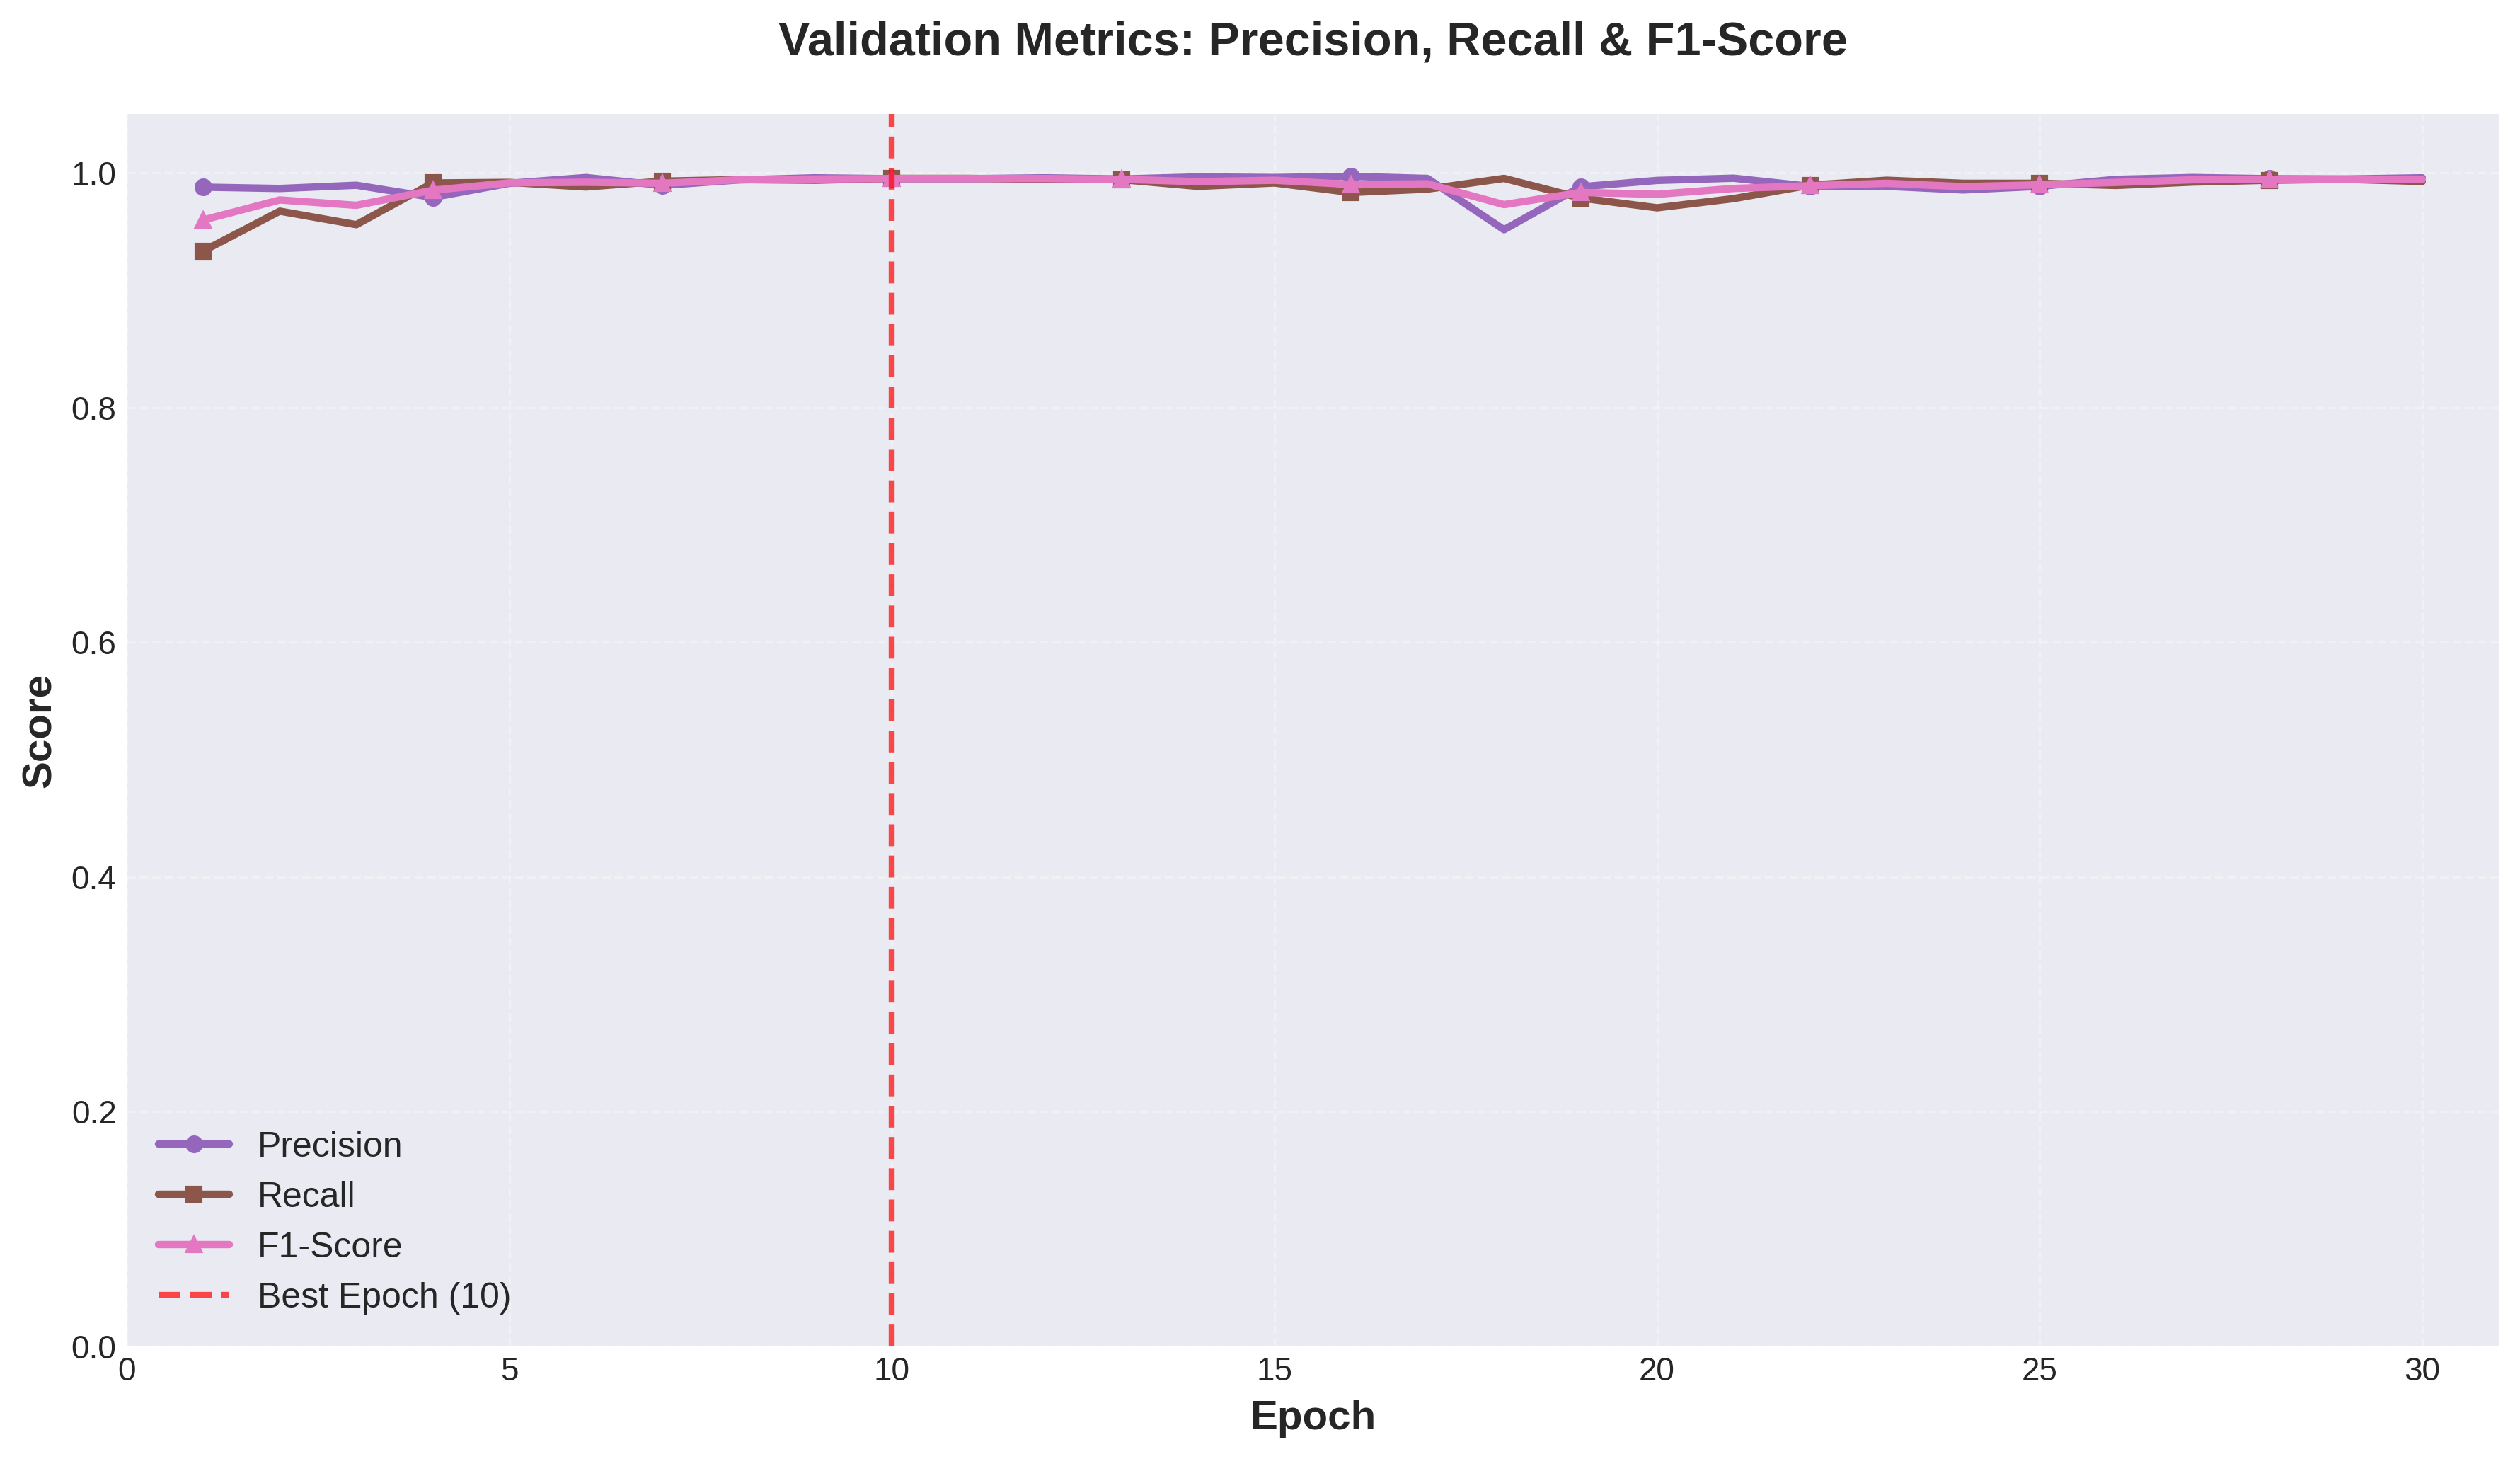

6️⃣  Generating ROC Curve...
   ✓ Saved: 6_roc_curve.png


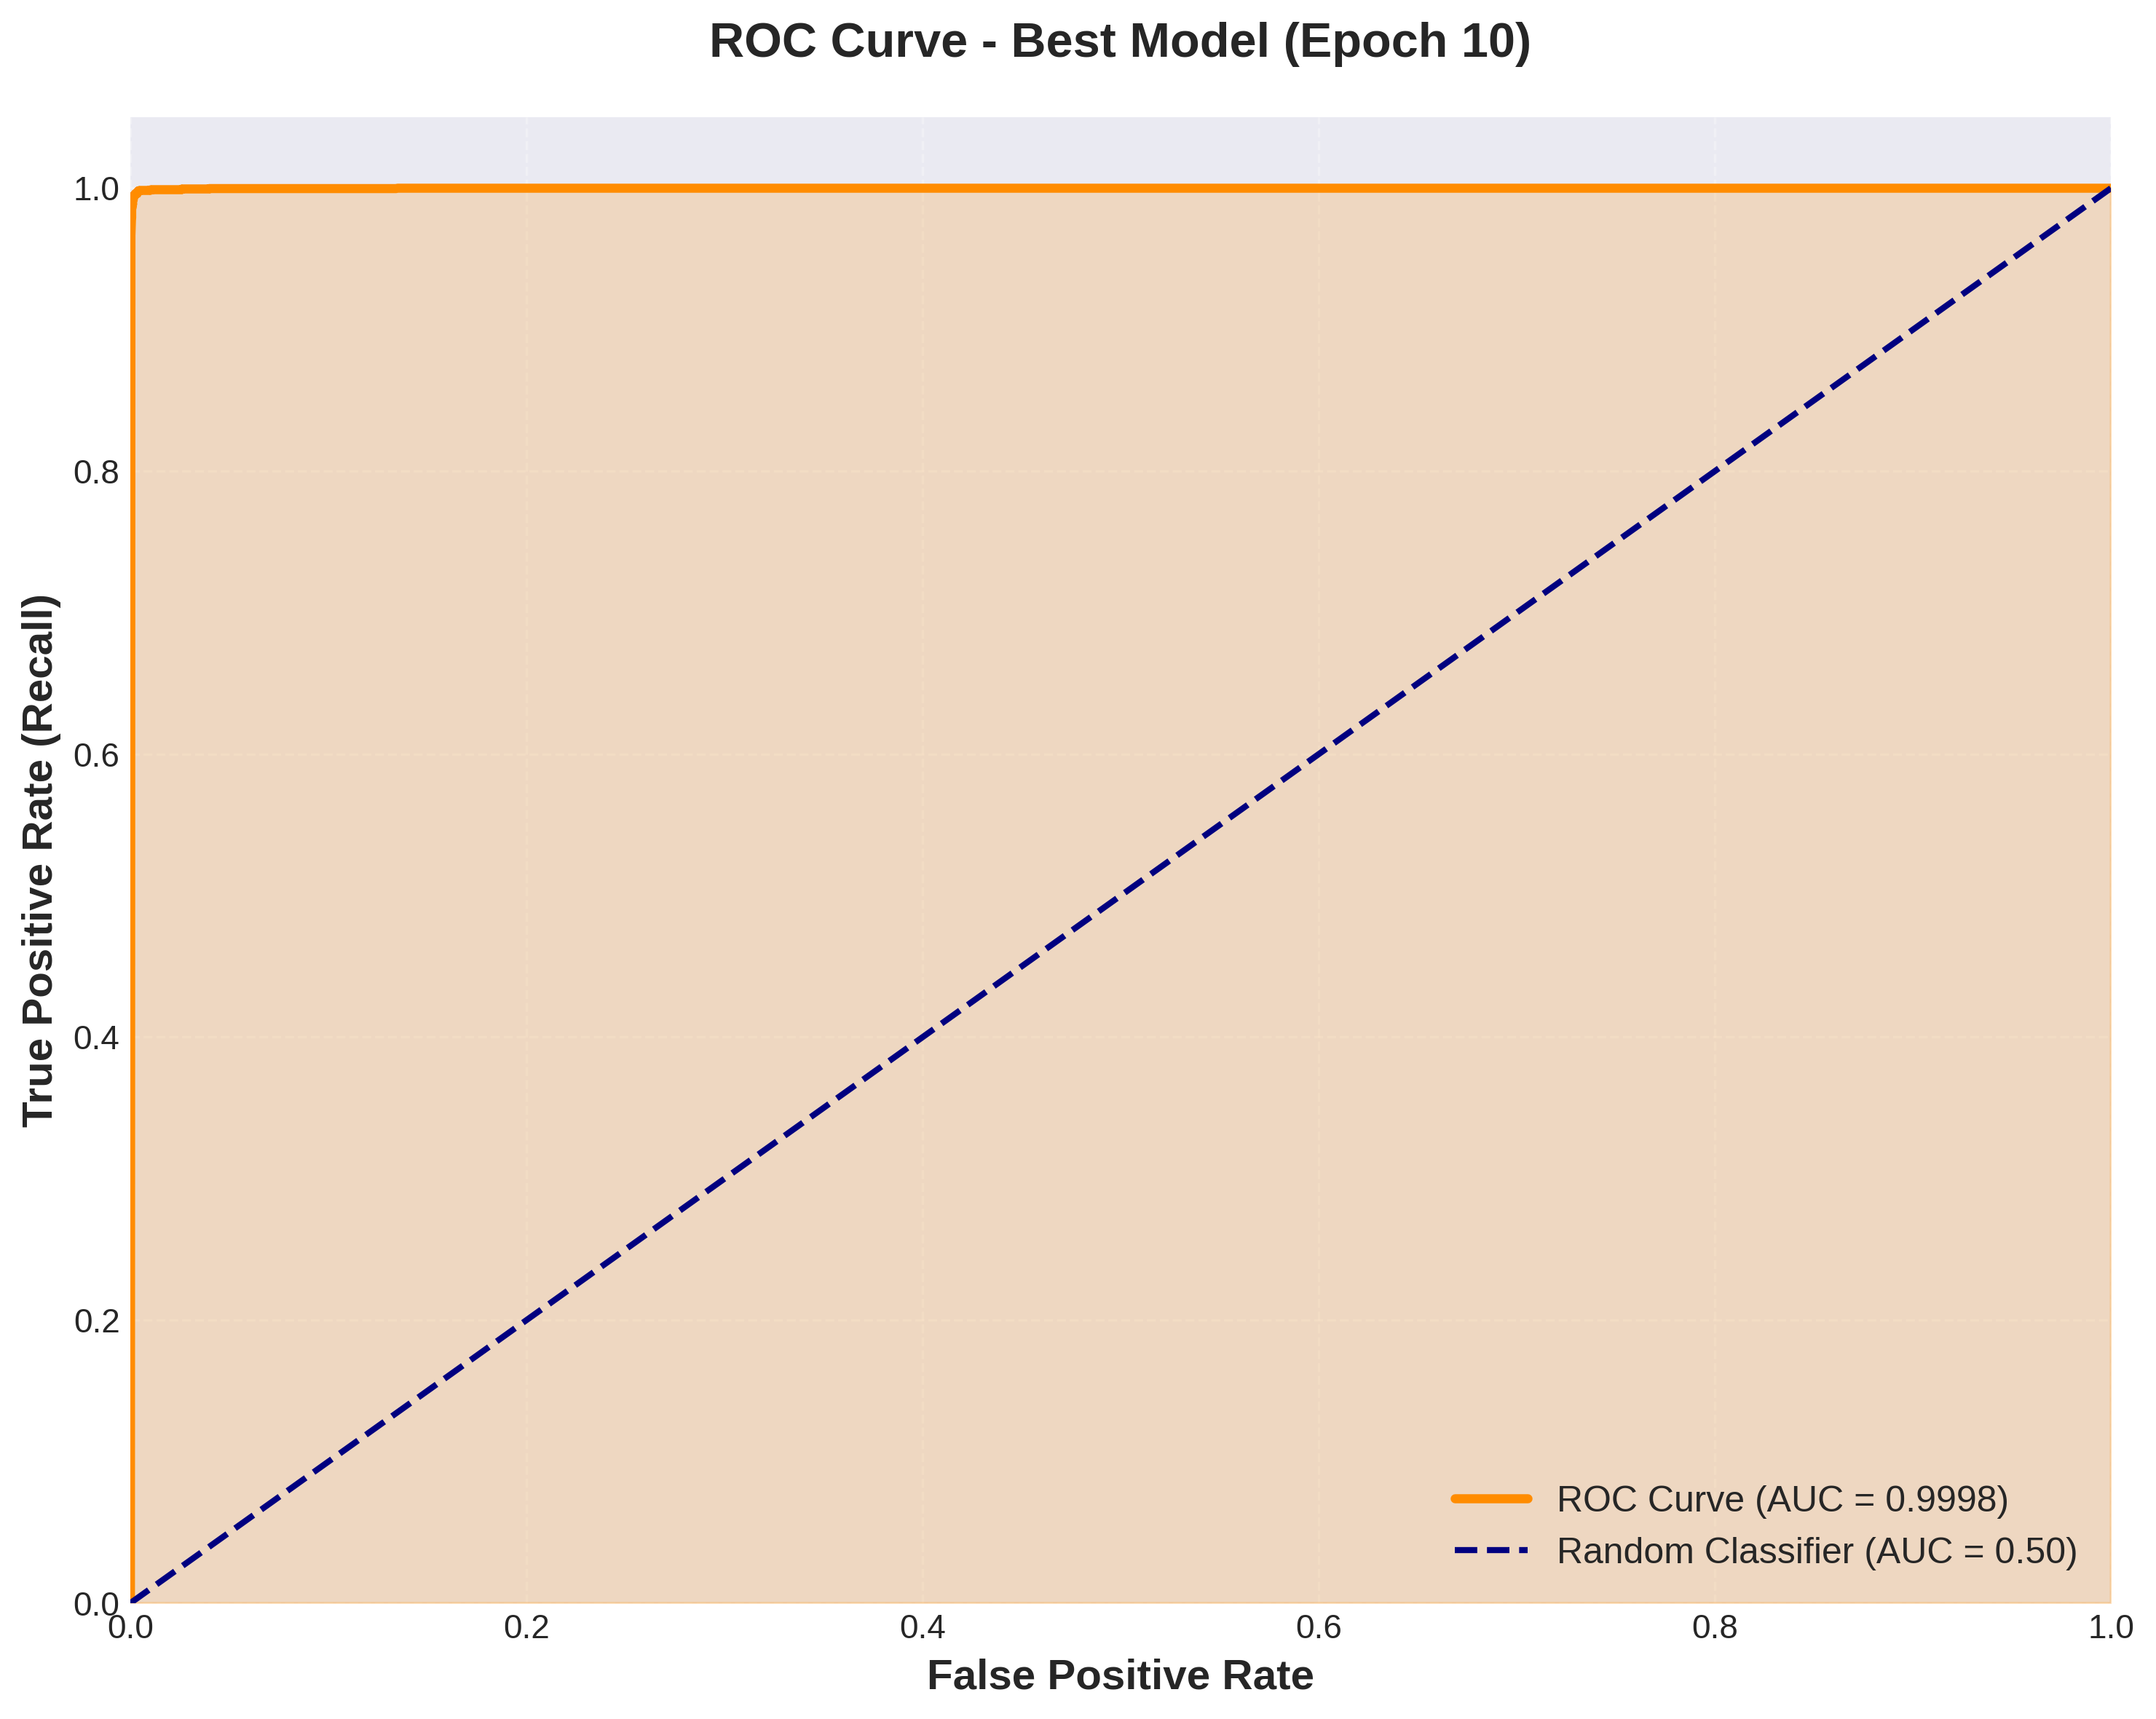

7️⃣  Generating Learning Rate Schedule...
   ✓ Saved: 7_learning_rate_schedule.png


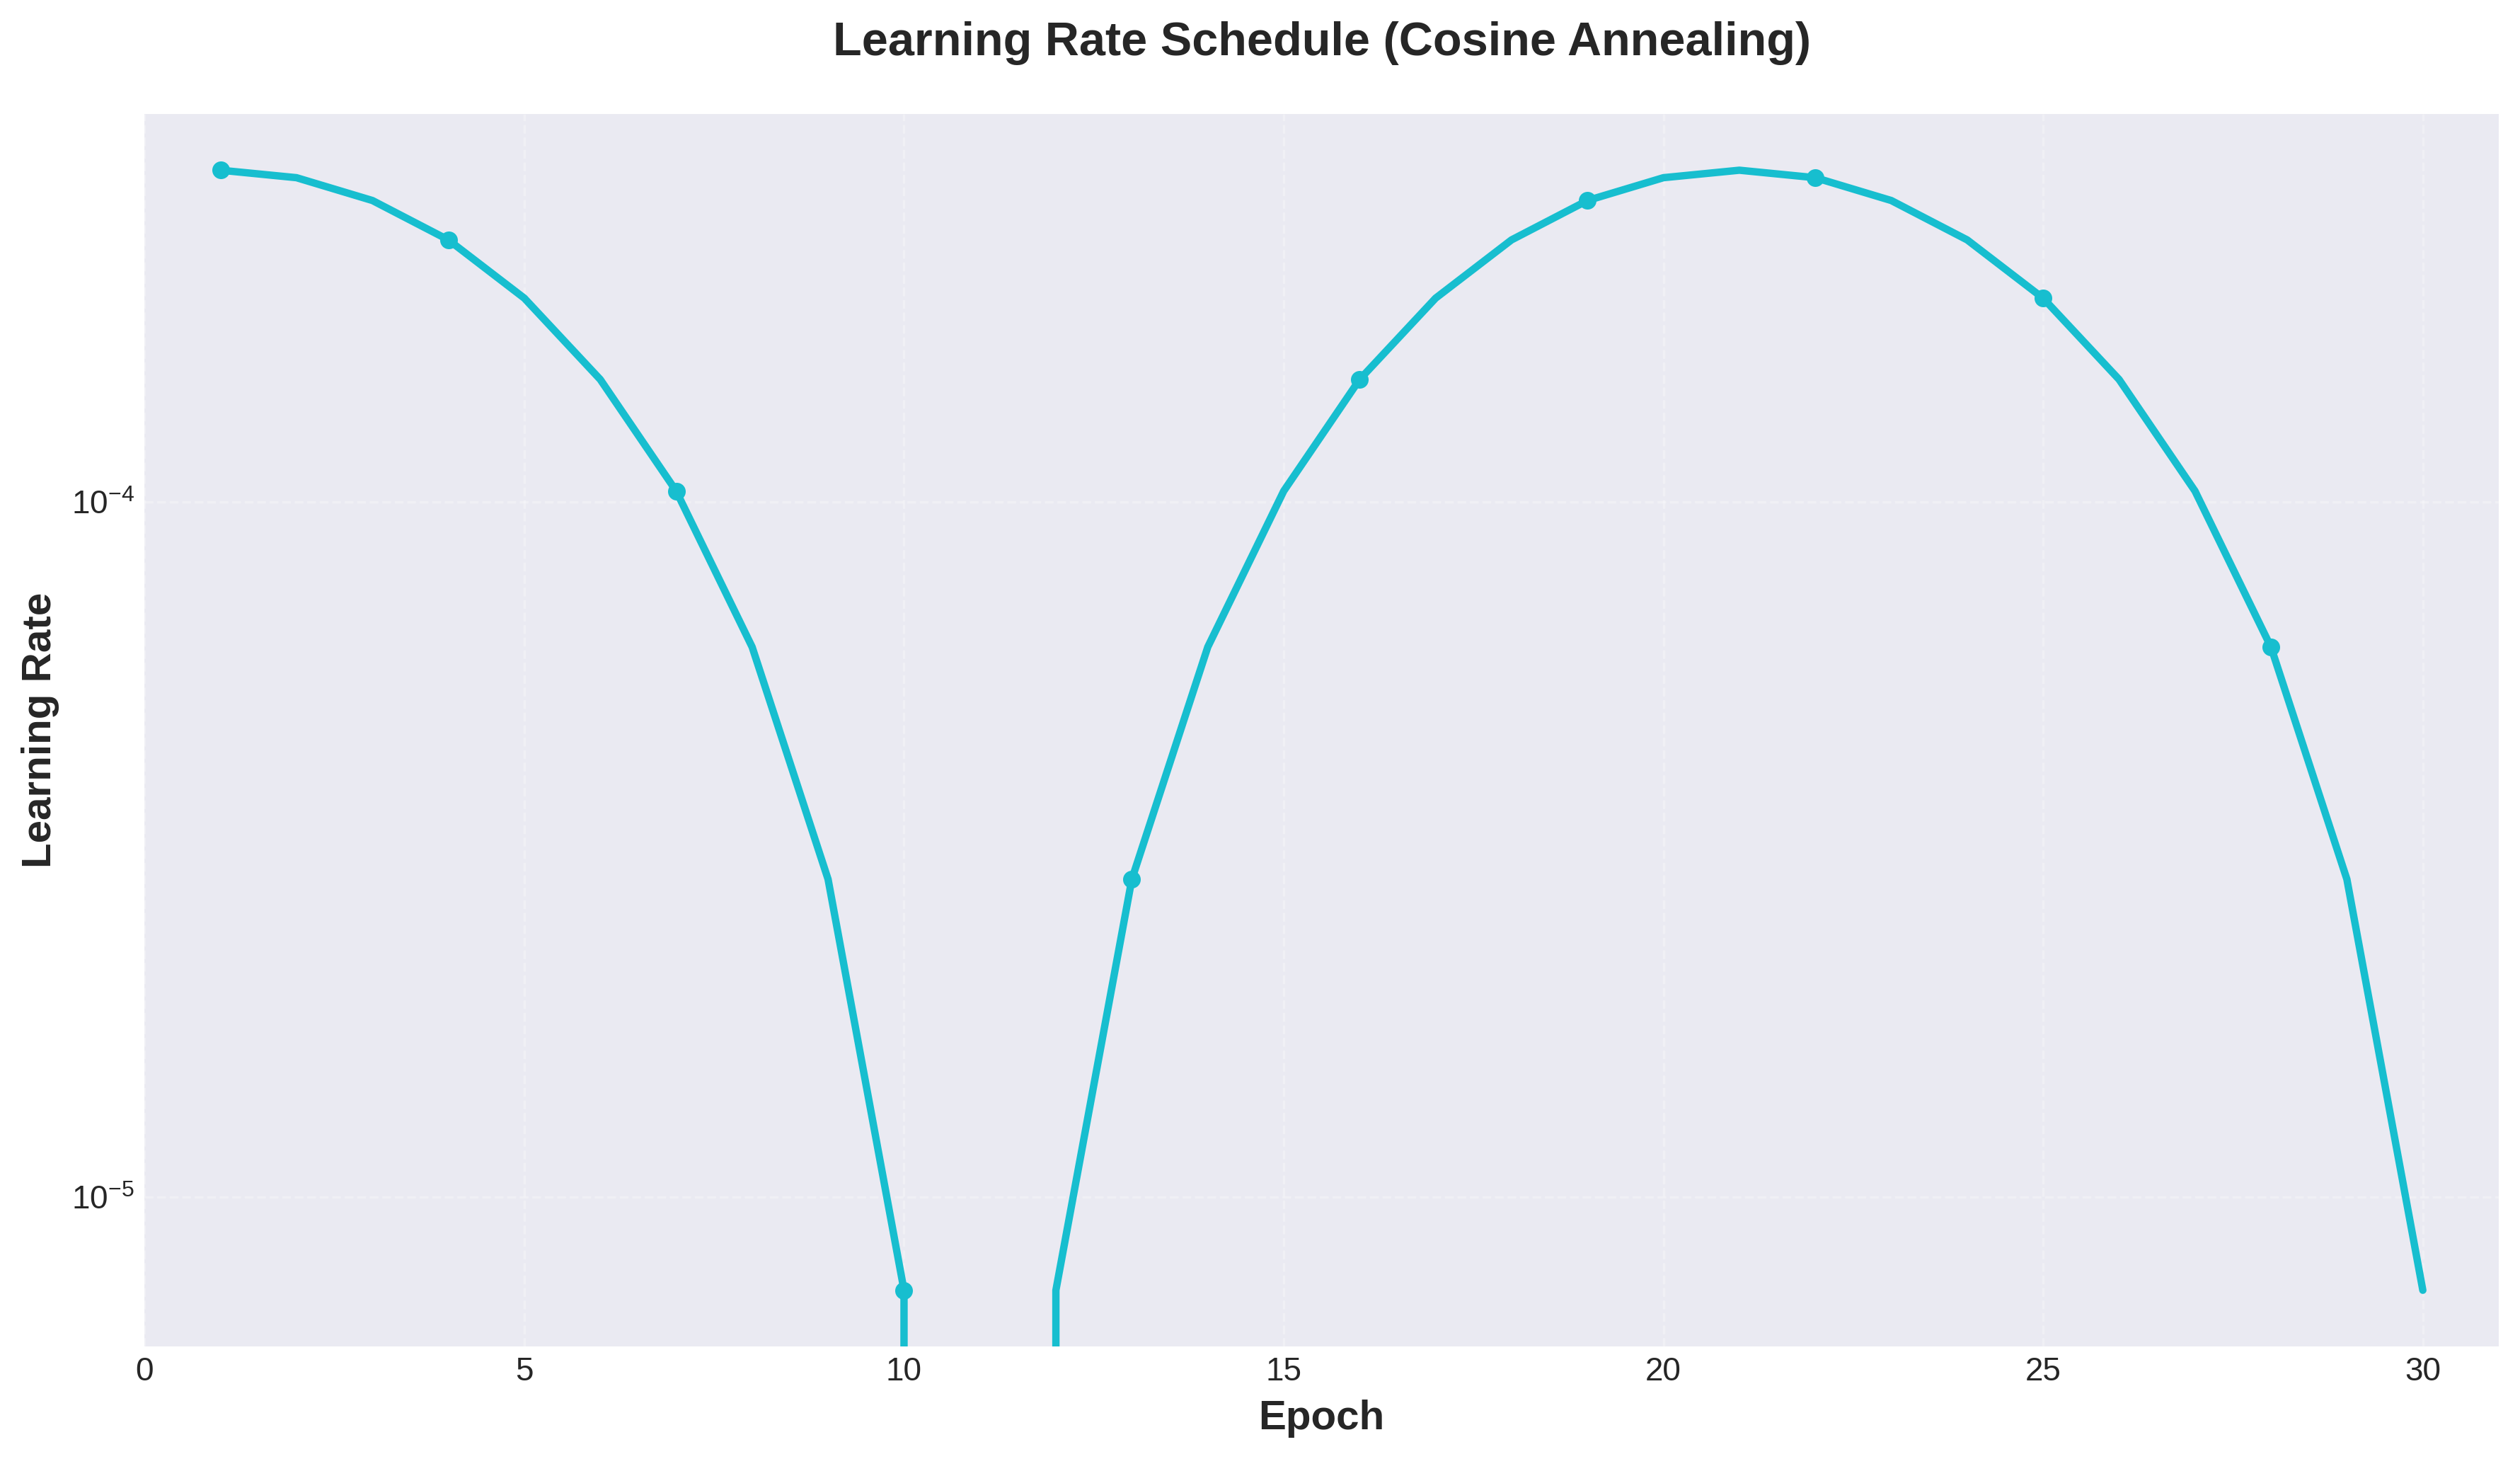

8️⃣  Creating Metrics Summary Table...
   ✓ Saved: 8_metrics_summary_table.png


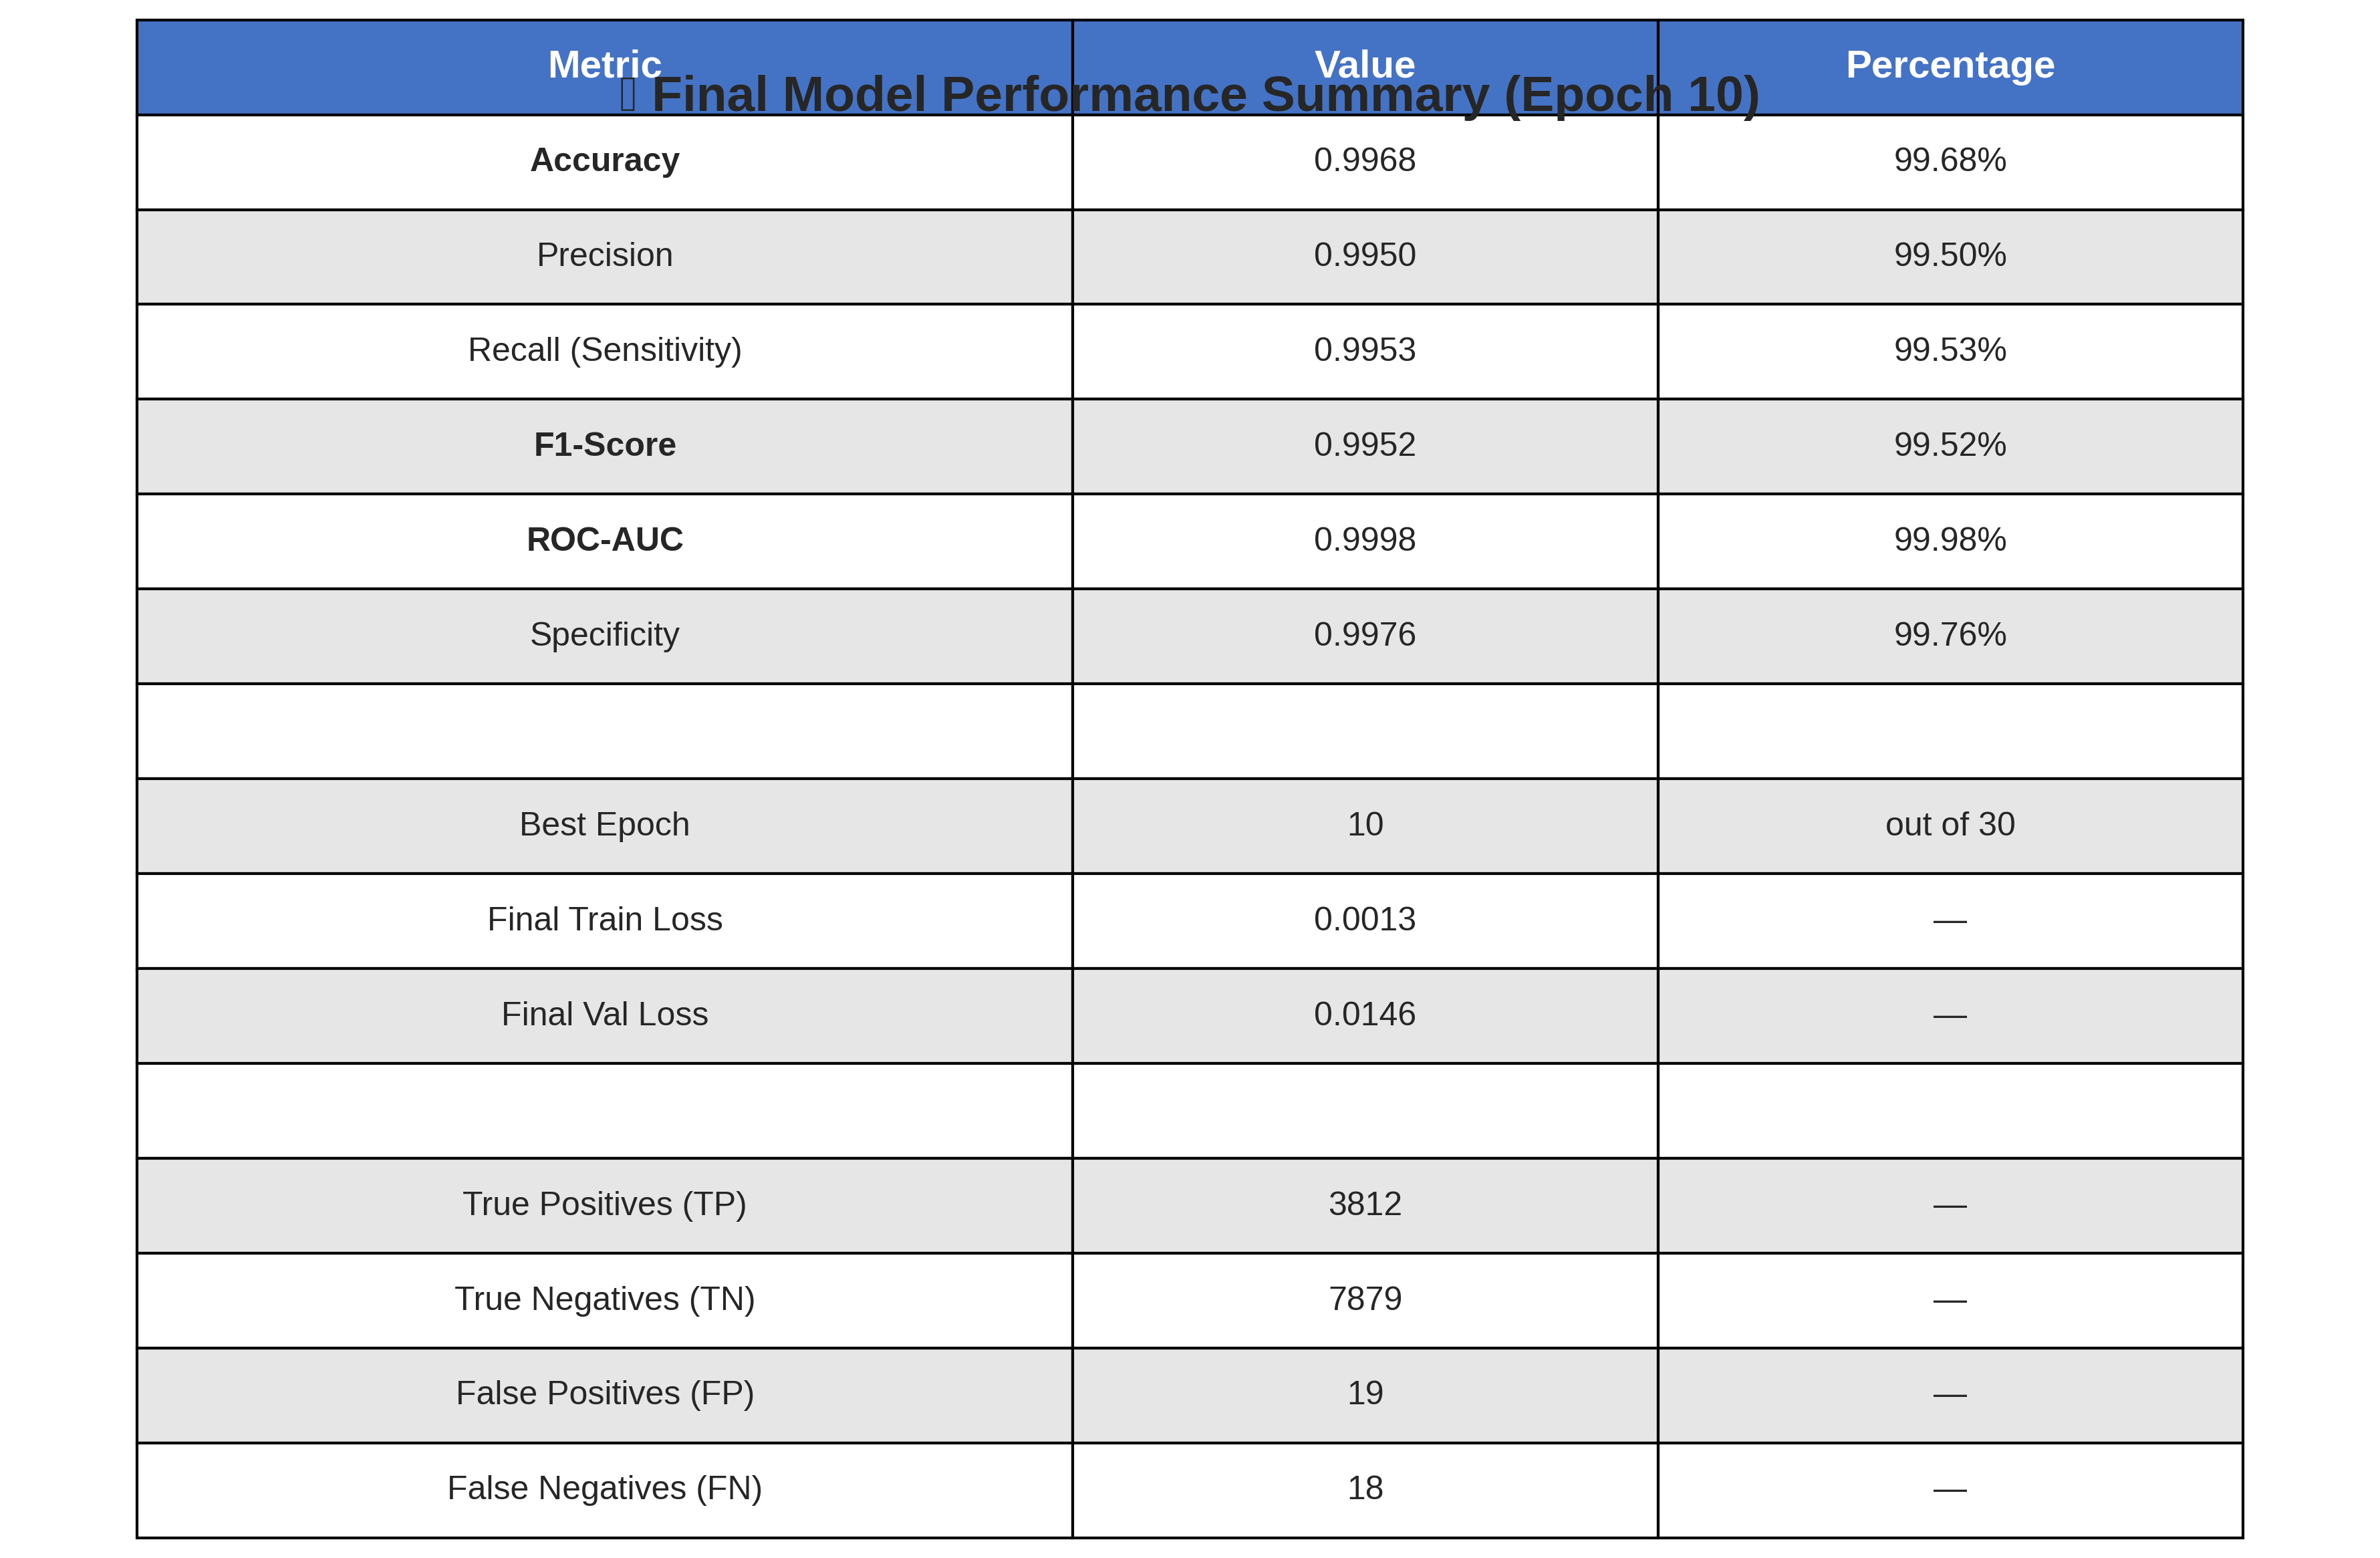


🎯 FINAL EVALUATION SUMMARY

🏆 Best Model Performance (Epoch 10):
   ├─ Accuracy : 99.68%
   ├─ Precision: 99.50%
   ├─ Recall   : 99.53%
   ├─ F1-Score : 99.52%
   └─ ROC-AUC  : 99.98%

📊 Confusion Matrix:
   ├─ True Positives : 3812
   ├─ True Negatives : 7879
   ├─ False Positives: 19
   └─ False Negatives: 18

📈 Training Statistics:
   ├─ Total Epochs Run: 30
   ├─ Best Epoch: 10
   ├─ Final Train Loss: 0.0013
   ├─ Final Val Loss: 0.0146
   └─ Early Stopped: Yes

📁 Generated Files:
   ├─ 1_confusion_matrix.png
   ├─ 2_loss_curve.png
   ├─ 3_accuracy_curve.png
   ├─ 4_f1_score_curve.png
   ├─ 5_precision_recall_f1.png
   ├─ 6_roc_curve.png
   ├─ 7_learning_rate_schedule.png
   └─ 8_metrics_summary_table.png

✅ ALL VISUALIZATIONS COMPLETE!


In [9]:
# ================================
# Cell 4: Comprehensive Visualization & Evaluation (Separate Images)
# Purpose: Generate all plots as separate high-quality images
# Runtime: ~15-25 seconds
# ================================

print("📊 Generating comprehensive evaluation visualizations...")
print("="*60)

# Set global plot style
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11


# ================================
# 1. CONFUSION MATRIX HEATMAP
# ================================
print("\n1️⃣  Generating Confusion Matrix...")
fig1, ax1 = plt.subplots(figsize=(10, 8))

cm = best_metrics['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Tumor (0)', 'Tumor (1)'],
            yticklabels=['No Tumor (0)', 'Tumor (1)'],
            ax=ax1, cbar_kws={'label': 'Count'}, annot_kws={'size': 14})

ax1.set_xlabel('Predicted Labels', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Labels', fontsize=14, fontweight='bold')
ax1.set_title(f'Confusion Matrix - Best Model (Epoch {best_epoch})', 
              fontsize=16, fontweight='bold', pad=20)

# Add metrics text below
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

metrics_text = f'Sensitivity (Recall): {sensitivity:.4f} | Specificity: {specificity:.4f} | Accuracy: {best_metrics["accuracy"]:.4f}'
plt.figtext(0.5, 0.02, metrics_text, ha='center', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/kaggle/working/1_confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 1_confusion_matrix.png")
plt.show()  # Display in notebook
plt.close()


# ================================
# 2. ACCURACY & LOSS CURVES (SIDE-BY-SIDE)
# ================================
print("2️⃣  Generating Accuracy & Loss Curves (Combined)...")

epochs_range = range(1, len(history['train_loss']) + 1)

# Create figure with 2 subplots side by side
fig2, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(16, 6))

# -------- (a) Accuracy Curve --------
ax_acc.plot(epochs_range, history['train_acc'], 
            label='train', linewidth=2.5, color='#1f77b4')
ax_acc.plot(epochs_range, history['val_acc'], 
            label='validation', linewidth=2.5, color='#ff7f0e')

ax_acc.set_xlabel('epoch', fontsize=12, fontweight='bold')
ax_acc.set_ylabel('accuracy', fontsize=12, fontweight='bold')
ax_acc.set_title('(a) Accuracy Curve', fontsize=14, fontweight='bold', loc='left', pad=15)
ax_acc.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax_acc.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax_acc.set_ylim([0.75, 1.0])  


# ================================
# 4. F1-SCORE CURVE (STANDALONE)
# ================================
print("4️⃣  Generating F1-Score Curve...")
fig4, ax4 = plt.subplots(figsize=(12, 7))

ax4.plot(epochs_range, history['val_f1'], 
         label='Validation F1-Score', marker='^', linewidth=2.5, markersize=6, 
         color='#e377c2', markevery=max(1, len(epochs_range)//10))
ax4.axvline(x=best_epoch, color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')

# Add best F1 annotation
ax4.annotate(f'Best F1: {best_val_f1:.4f}', 
             xy=(best_epoch, best_val_f1), 
             xytext=(best_epoch+2, best_val_f1-0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red', fontweight='bold')

ax4.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax4.set_ylabel('F1-Score', fontsize=14, fontweight='bold')
ax4.set_title('Validation F1-Score Curve', fontsize=16, fontweight='bold', pad=20)
ax4.legend(loc='best', fontsize=12, framealpha=0.9)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_ylim([0, 1.05])
ax4.set_xlim([0, len(epochs_range)+1])

plt.tight_layout()
plt.savefig('/kaggle/working/4_f1_score_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 4_f1_score_curve.png")
plt.show()  # Display in notebook
plt.close()


# ================================
# 5. PRECISION, RECALL, F1-SCORE (COMBINED)
# ================================
print("5️⃣  Generating Precision/Recall/F1 Combined Curve...")
fig5, ax5 = plt.subplots(figsize=(12, 7))

ax5.plot(epochs_range, history['val_precision'], 
         label='Precision', marker='o', linewidth=2.5, markersize=5, 
         color='#9467bd', markevery=max(1, len(epochs_range)//10))
ax5.plot(epochs_range, history['val_recall'], 
         label='Recall', marker='s', linewidth=2.5, markersize=5, 
         color='#8c564b', markevery=max(1, len(epochs_range)//10))
ax5.plot(epochs_range, history['val_f1'], 
         label='F1-Score', marker='^', linewidth=2.5, markersize=5, 
         color='#e377c2', markevery=max(1, len(epochs_range)//10))
ax5.axvline(x=best_epoch, color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')

ax5.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax5.set_ylabel('Score', fontsize=14, fontweight='bold')
ax5.set_title('Validation Metrics: Precision, Recall & F1-Score', 
              fontsize=16, fontweight='bold', pad=20)
ax5.legend(loc='best', fontsize=12, framealpha=0.9)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_ylim([0, 1.05])
ax5.set_xlim([0, len(epochs_range)+1])

plt.tight_layout()
plt.savefig('/kaggle/working/5_precision_recall_f1.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 5_precision_recall_f1.png")
plt.show()  # Display in notebook
plt.close()


# ================================
# 6. ROC CURVE WITH AUC
# ================================
print("6️⃣  Generating ROC Curve...")
fig6, ax6 = plt.subplots(figsize=(10, 8))

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(best_val_targets, best_val_probs)
roc_auc = auc(fpr, tpr)

ax6.plot(fpr, tpr, color='darkorange', linewidth=3, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', linewidth=2, 
         linestyle='--', label='Random Classifier (AUC = 0.50)')
ax6.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

ax6.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
ax6.set_ylabel('True Positive Rate (Recall)', fontsize=14, fontweight='bold')
ax6.set_title(f'ROC Curve - Best Model (Epoch {best_epoch})', 
              fontsize=16, fontweight='bold', pad=20)
ax6.legend(loc='lower right', fontsize=12, framealpha=0.9)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])

# Add diagonal reference
plt.tight_layout()
plt.savefig('/kaggle/working/6_roc_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 6_roc_curve.png")
plt.show()  # Display in notebook
plt.close()


# ================================
# 7. LEARNING RATE SCHEDULE
# ================================
print("7️⃣  Generating Learning Rate Schedule...")
fig7, ax7 = plt.subplots(figsize=(12, 7))

ax7.plot(epochs_range, history['learning_rates'], 
         marker='o', linewidth=2.5, markersize=5, color='#17becf',
         markevery=max(1, len(epochs_range)//10))
ax7.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax7.set_ylabel('Learning Rate', fontsize=14, fontweight='bold')
ax7.set_title('Learning Rate Schedule (Cosine Annealing)', 
              fontsize=16, fontweight='bold', pad=20)
ax7.grid(True, alpha=0.3, linestyle='--')
ax7.set_yscale('log')
ax7.set_xlim([0, len(epochs_range)+1])

plt.tight_layout()
plt.savefig('/kaggle/working/7_learning_rate_schedule.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 7_learning_rate_schedule.png")
plt.show()  # Display in notebook
plt.close()


# ================================
# 8. METRICS SUMMARY TABLE (AS IMAGE)
# ================================
print("8️⃣  Creating Metrics Summary Table...")
fig8, ax8 = plt.subplots(figsize=(12, 8))
ax8.axis('off')

# Create comprehensive table data
table_data = [
    ['Metric', 'Value', 'Percentage'],
    ['Accuracy', f'{best_metrics["accuracy"]:.4f}', f'{best_metrics["accuracy"]*100:.2f}%'],
    ['Precision', f'{best_metrics["precision"]:.4f}', f'{best_metrics["precision"]*100:.2f}%'],
    ['Recall (Sensitivity)', f'{best_metrics["recall"]:.4f}', f'{best_metrics["recall"]*100:.2f}%'],
    ['F1-Score', f'{best_metrics["f1_score"]:.4f}', f'{best_metrics["f1_score"]*100:.2f}%'],
    ['ROC-AUC', f'{roc_auc:.4f}', f'{roc_auc*100:.2f}%'],
    ['Specificity', f'{specificity:.4f}', f'{specificity*100:.2f}%'],
    ['', '', ''],
    ['Best Epoch', f'{best_epoch}', f'out of {len(history["train_loss"])}'],
    ['Final Train Loss', f'{history["train_loss"][-1]:.4f}', '—'],
    ['Final Val Loss', f'{history["val_loss"][-1]:.4f}', '—'],
    ['', '', ''],
    ['True Positives (TP)', f'{tp}', '—'],
    ['True Negatives (TN)', f'{tn}', '—'],
    ['False Positives (FP)', f'{fp}', '—'],
    ['False Negatives (FN)', f'{fn}', '—'],
]

table = ax8.table(cellText=table_data, cellLoc='center', loc='center',
                  colWidths=[0.4, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3)

# Style header row
for i in range(3):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white', size=14)

# Style metric rows
for i in range(1, len(table_data)):
    if table_data[i][0] == '':  # Empty rows for spacing
        for j in range(3):
            table[(i, j)].set_facecolor('#FFFFFF')
    elif i % 2 == 0:
        for j in range(3):
            table[(i, j)].set_facecolor('#E7E6E6')
    
    # Bold important metrics
    if i in [1, 4, 5]:  # Accuracy, F1, AUC
        table[(i, 0)].set_text_props(weight='bold')

ax8.set_title(f'📋 Final Model Performance Summary (Epoch {best_epoch})', 
              fontsize=18, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('/kaggle/working/8_metrics_summary_table.png', dpi=300, bbox_inches='tight', facecolor='white')
print("   ✓ Saved: 8_metrics_summary_table.png")
plt.show()  # Display in notebook
plt.close()


# ================================
# PRINT FINAL SUMMARY TO CONSOLE
# ================================
print("\n" + "="*60)
print("🎯 FINAL EVALUATION SUMMARY")
print("="*60)
print(f"\n🏆 Best Model Performance (Epoch {best_epoch}):")
print(f"   ├─ Accuracy : {best_metrics['accuracy']*100:.2f}%")
print(f"   ├─ Precision: {best_metrics['precision']*100:.2f}%")
print(f"   ├─ Recall   : {best_metrics['recall']*100:.2f}%")
print(f"   ├─ F1-Score : {best_metrics['f1_score']*100:.2f}%")
print(f"   └─ ROC-AUC  : {roc_auc*100:.2f}%")

print(f"\n📊 Confusion Matrix:")
print(f"   ├─ True Positives : {tp}")
print(f"   ├─ True Negatives : {tn}")
print(f"   ├─ False Positives: {fp}")
print(f"   └─ False Negatives: {fn}")

print(f"\n📈 Training Statistics:")
print(f"   ├─ Total Epochs Run: {len(history['train_loss'])}")
print(f"   ├─ Best Epoch: {best_epoch}")
print(f"   ├─ Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"   ├─ Final Val Loss: {history['val_loss'][-1]:.4f}")
print(f"   └─ Early Stopped: {'Yes' if len(history['train_loss']) < max_epochs else 'No'}")

print("\n📁 Generated Files:")
print("   ├─ 1_confusion_matrix.png")
print("   ├─ 2_loss_curve.png")
print("   ├─ 3_accuracy_curve.png")
print("   ├─ 4_f1_score_curve.png")
print("   ├─ 5_precision_recall_f1.png")
print("   ├─ 6_roc_curve.png")
print("   ├─ 7_learning_rate_schedule.png")
print("   └─ 8_metrics_summary_table.png")

print("\n" + "="*60)
print("✅ ALL VISUALIZATIONS COMPLETE!")
print("="*60)

📊 Generating Combined Accuracy & Loss Curves...
✓ Loaded training history from saved files
✓ Best epoch: 10

📈 Plotting Accuracy Curve...
📉 Plotting Loss Curve...

✅ Combined curve generated successfully!
📁 Saved as: accuracy_loss_combined.png
   Location: /kaggle/working/


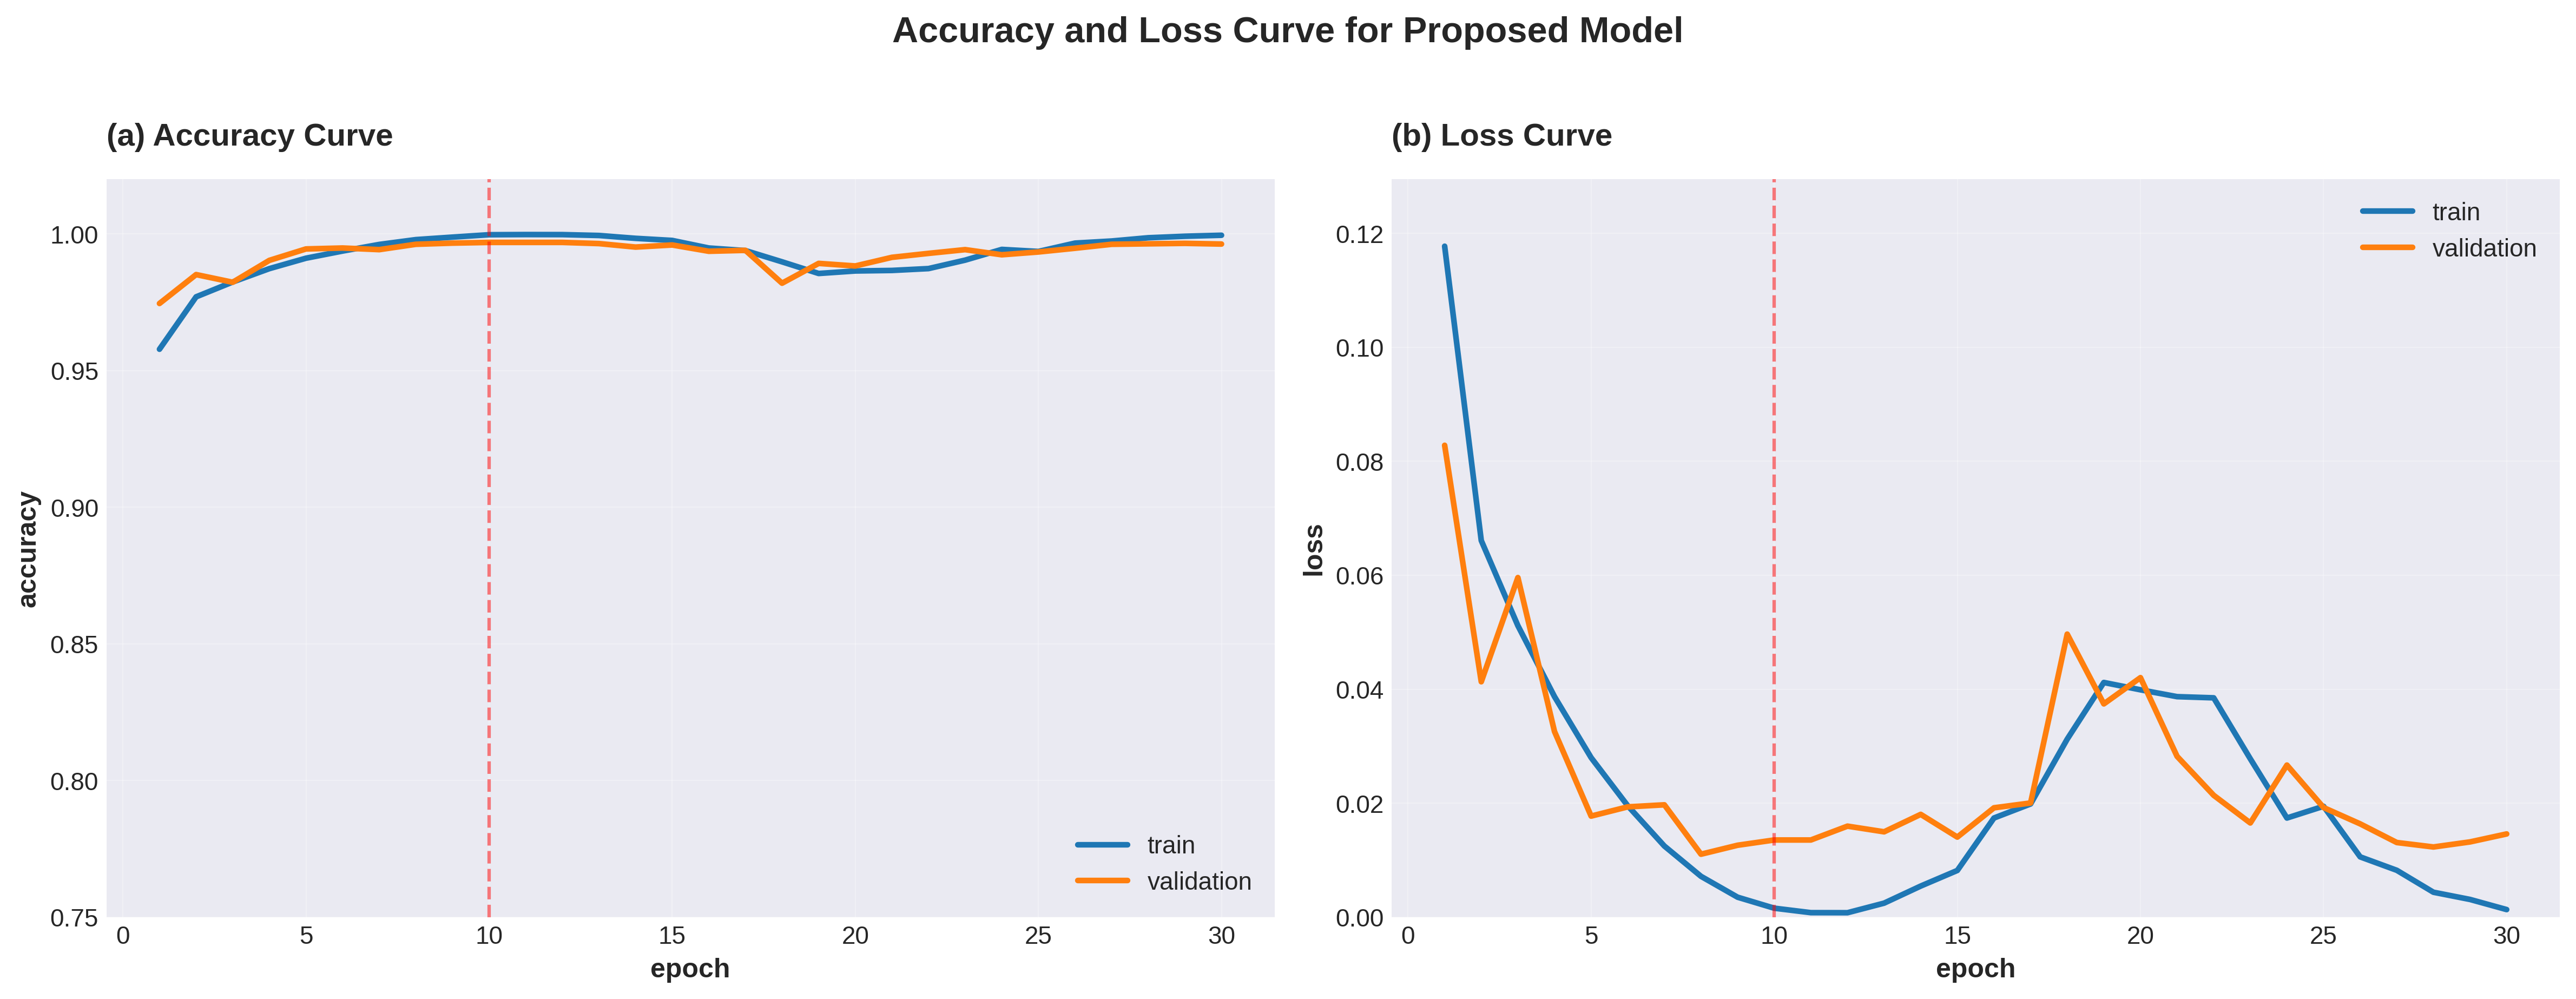


📊 Plot Summary:
   ├─ Total Epochs: 30
   ├─ Best Epoch: 10
   ├─ Final Train Acc: 0.9995
   ├─ Final Val Acc: 0.9962
   ├─ Final Train Loss: 0.0013
   └─ Final Val Loss: 0.0146
✓ You can now find 'accuracy_loss_combined.png' in Output tab


In [11]:
# ================================
# Cell 5: Generate Accuracy & Loss Curves (Side-by-Side)
# Purpose: Create a single figure with accuracy and loss curves together
# Runtime: ~5 seconds
# ================================

import matplotlib.pyplot as plt
import numpy as np

print("📊 Generating Combined Accuracy & Loss Curves...")
print("="*60)

# Load saved history (if running this cell separately)
try:
    history = np.load('/kaggle/working/training_history.npy', allow_pickle=True).item()
    best_metrics = np.load('/kaggle/working/best_metrics.npy', allow_pickle=True).item()
    print("✓ Loaded training history from saved files")
    
    # Find best epoch
    best_epoch = np.argmax(history['val_f1']) + 1
    print(f"✓ Best epoch: {best_epoch}")
except:
    print("⚠️ Using history from current session")

epochs_range = range(1, len(history['train_loss']) + 1)

# ================================
# Create Side-by-Side Subplots
# ================================
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(16, 6))

# Set background color
fig.patch.set_facecolor('white')

# ================================
# (a) ACCURACY CURVE
# ================================
print("\n📈 Plotting Accuracy Curve...")
ax_acc.plot(epochs_range, history['train_acc'], 
            label='train', linewidth=2.5, color='#1f77b4')
ax_acc.plot(epochs_range, history['val_acc'], 
            label='validation', linewidth=2.5, color='#ff7f0e')

ax_acc.set_xlabel('epoch', fontsize=12, fontweight='bold')
ax_acc.set_ylabel('accuracy', fontsize=12, fontweight='bold')
ax_acc.set_title('(a) Accuracy Curve', fontsize=14, fontweight='bold', 
                 loc='left', pad=15)
ax_acc.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax_acc.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax_acc.set_ylim([0.75, 1.02])

# Add best epoch marker
try:
    if best_epoch:
        ax_acc.axvline(x=best_epoch, color='red', linestyle='--', 
                       linewidth=1.5, alpha=0.5)
except:
    pass

# ================================
# (b) LOSS CURVE
# ================================
print("📉 Plotting Loss Curve...")
ax_loss.plot(epochs_range, history['train_loss'], 
             label='train', linewidth=2.5, color='#1f77b4')
ax_loss.plot(epochs_range, history['val_loss'], 
             label='validation', linewidth=2.5, color='#ff7f0e')

ax_loss.set_xlabel('epoch', fontsize=12, fontweight='bold')
ax_loss.set_ylabel('loss', fontsize=12, fontweight='bold')
ax_loss.set_title('(b) Loss Curve', fontsize=14, fontweight='bold', 
                  loc='left', pad=15)
ax_loss.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax_loss.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Set y-axis limits for better visibility
max_loss = max(max(history['train_loss']), max(history['val_loss']))
ax_loss.set_ylim([0, max_loss * 1.1])

# Add best epoch marker
try:
    if best_epoch:
        ax_loss.axvline(x=best_epoch, color='red', linestyle='--', 
                        linewidth=1.5, alpha=0.5)
except:
    pass

# ================================
# Add Main Title
# ================================
plt.suptitle('Accuracy and Loss Curve for Proposed Model', 
             fontsize=16, fontweight='bold', y=1.02)

# ================================
# Save Figure
# ================================
plt.tight_layout()
plt.savefig('/kaggle/working/accuracy_loss_combined.png', 
            dpi=300, bbox_inches='tight', facecolor='white')

print("\n✅ Combined curve generated successfully!")
print("📁 Saved as: accuracy_loss_combined.png")
print("   Location: /kaggle/working/")

# Display the plot
plt.show()

# Print summary
print("\n" + "="*60)
print("📊 Plot Summary:")
print(f"   ├─ Total Epochs: {len(epochs_range)}")
print(f"   ├─ Best Epoch: {best_epoch if 'best_epoch' in locals() else 'N/A'}")
print(f"   ├─ Final Train Acc: {history['train_acc'][-1]:.4f}")
print(f"   ├─ Final Val Acc: {history['val_acc'][-1]:.4f}")
print(f"   ├─ Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"   └─ Final Val Loss: {history['val_loss'][-1]:.4f}")
print("="*60)
print("✓ You can now find 'accuracy_loss_combined.png' in Output tab")
print("="*60)